# Tutorial 7 — Linear Regression and Bambi

**Statistical Computation and Analysis — Spring 2026**

In this tutorial we use the radon dataset to study linear regression in both Bayesian and frequentist frameworks.

Main goals:

1. Move from the Normal model to simple linear regression.
2. Understand centering, normalization, and standardization.
3. Fit a simple Bayesian linear regression model in PyMC.
4. Fit multiple regression using PyMC and Bambi.
5. Compare Bayesian regression with frequentist OLS, including $R^2$, adjusted $R^2$, and the $F$-test.

We will use `log_radon` as the dependent variable. Predictors will include county uranium level and basement status.

## 1. Setup

The setup cells prepare the Colab environment, import the required packages, and set plotting defaults.

Important compatibility note:

- The course notebooks use the classic ArviZ API, including `az.plot_ppc()`.
- We therefore check that ArviZ is a course-compatible pre-1.0 version.
- Prior predictive samples are first saved separately, then added to the model `InferenceData` object with `.extend()`, as in previous tutorials.
- Posterior predictive samples are added to the same `InferenceData` object using `extend_inferencedata=True`.

In [ ]:
# ------------------------------------------------------------
# Course package versions
# ------------------------------------------------------------
# Run this cell first.
#
# If packages are installed or changed, restart the runtime and
# then run the notebook again from the beginning.
# ------------------------------------------------------------

import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version

IS_COLAB = "google.colab" in sys.modules

COURSE_PACKAGE_VERSIONS = {
    "arviz": "0.22.0",
    "matplotlib": "3.10.0",
    "numpy": "2.0.2",
    "pandas": "2.2.2",
    "pymc": "5.28.4",
    "scipy": "1.16.3",
    "seaborn": "0.13.2",
}

# Additional packages used in this tutorial.
# These are not pinned unless needed.
EXTRA_PACKAGES = {
    "bambi": None,
    "statsmodels": None,
    "preliz": None,
    "packaging": None,
    "graphviz": None,
}

packages_to_install = []

for package_name, required_version in COURSE_PACKAGE_VERSIONS.items():
    try:
        current_version = version(package_name)
        print(f"{package_name:10s}: {current_version}")

        if Version(current_version) != Version(required_version):
            packages_to_install.append(f"{package_name}=={required_version}")

    except PackageNotFoundError:
        packages_to_install.append(f"{package_name}=={required_version}")

for package_name in EXTRA_PACKAGES:
    try:
        current_version = version(package_name)
        print(f"{package_name:10s}: {current_version}")
    except PackageNotFoundError:
        packages_to_install.append(package_name)

if len(packages_to_install) > 0:
    print("\nInstalling/updating packages:")
    for package in packages_to_install:
        print(" -", package)

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        *packages_to_install,
    ])

    print("\nPackages were installed or changed.")
    print("Restart the runtime now, then run all cells again from the beginning.")
    raise SystemExit("Restart the runtime, then run all cells again from the beginning.")
else:
    print("\nAll required course package versions are already installed.")

# ------------------------------------------------------------
# Imports and version check
# ------------------------------------------------------------

from pathlib import Path
import urllib.request
import warnings

import arviz as az
import bambi as bmb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import scipy
import scipy.stats as stats
import seaborn as sns
import statsmodels
import statsmodels.formula.api as smf

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"arviz     : {az.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"numpy     : {np.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"pymc      : {pm.__version__}")
print(f"scipy     : {scipy.__version__}")
print(f"seaborn   : {sns.__version__}")
print(f"bambi     : {bmb.__version__}")
print(f"preliz    : {pz.__version__}")
print(f"statsmodels: {statsmodels.__version__}")

assert az.__version__ == "0.22.0"
assert matplotlib.__version__ == "3.10.0"
assert np.__version__ == "2.0.2"
assert pd.__version__ == "2.2.2"
assert pm.__version__ == "5.28.4"
assert scipy.__version__ == "1.16.3"
assert sns.__version__ == "0.13.2"

RANDOM_SEED = 17
rng = np.random.default_rng(RANDOM_SEED)

az.style.use("arviz-whitegrid")
sns.set_context("notebook")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

HDI_MASS = 0.94

print("Colab detected:", IS_COLAB)

arviz     : 0.22.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
pymc      : 5.28.4
scipy     : 1.16.3
seaborn   : 0.13.2
bambi     : 0.17.2
statsmodels: 0.14.6
preliz    : 0.24.0
packaging : 26.2
graphviz  : 0.21

All required course package versions are already installed.
arviz     : 0.22.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
pymc      : 5.28.4
scipy     : 1.16.3
seaborn   : 0.13.2
bambi     : 0.17.2
preliz    : 0.24.0
statsmodels: 0.14.6
Colab detected: True


## 2. Load the radon dataset

The notebook first looks for a local radon file. If no file is found, it downloads the same public `radon.csv` used in previous course material.

Expected columns:

- `log_radon` — log radon level, our dependent variable.
- `Uppm` — county uranium level in ppm.
- `basement` — whether the house has a basement (`Y` / `N`).
- `county` — county name.

In [ ]:
# ------------------------------------------------------------
# Resolve the radon data file
# ------------------------------------------------------------
# The notebook first searches for a local radon file.
# If no local file is found, it downloads the public radon.csv that was
# used in previous course material.
# ------------------------------------------------------------

RADON_URL = "https://raw.githubusercontent.com/BayesianModelingandComputationInPython/BookCode_Edition1/main/exercises/data/radon.csv"

SEARCH_FILENAMES = [
    "radon.csv",
    "Radon.csv",
    "radon_data.csv",
    "radon_dataset.csv",
]

SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("/content"),
    Path("/content/data"),
]


def find_local_radon_file():
    """Find a radon CSV file in common Colab/local locations."""
    for directory in SEARCH_DIRS:
        for filename in SEARCH_FILENAMES:
            candidate = directory / filename
            if candidate.exists():
                return candidate
    return None


radon_path = find_local_radon_file()

if radon_path is None and IS_COLAB:
    # If a file was uploaded manually to Colab but has a different name,
    # this tries to use the first CSV file in the current directory.
    csv_files = list(Path(".").glob("*.csv")) + list(Path("/content").glob("*.csv"))
    if len(csv_files) > 0:
        radon_path = csv_files[0]

if radon_path is None:
    print("No local radon file found. Downloading public radon.csv...")
    radon_path = Path("radon.csv")
    urllib.request.urlretrieve(RADON_URL, radon_path)
else:
    print(f"Using local file: {radon_path}")

radon_raw = pd.read_csv(radon_path)

print("Dataset shape:", radon_raw.shape)
display(radon_raw.head())
print("Columns:")
print(radon_raw.columns.tolist())

No local radon file found. Downloading public radon.csv...
Dataset shape: (919, 30)


,Unnamed: 0,idnum,state,state2,stfips,zip,region,typebldg,floor,room,...,pcterr,adjwt,dupflag,zipflag,cntyfips,county,fips,Uppm,county_code,log_radon
0,0,5081.0,MN,MN,27.0,55735,5.0,1.0,1.0,3.0,...,9.7,1146.499190,1.0,0.0,1.0,AITKIN,27001.0,0.502054,0,0.832909
1,1,5082.0,MN,MN,27.0,55748,5.0,1.0,0.0,4.0,...,14.5,471.366223,0.0,0.0,1.0,AITKIN,27001.0,0.502054,0,0.832909
2,2,5083.0,MN,MN,27.0,55748,5.0,1.0,0.0,4.0,...,9.6,433.316718,0.0,0.0,1.0,AITKIN,27001.0,0.502054,0,1.098612
3,3,5084.0,MN,MN,27.0,56469,5.0,1.0,0.0,4.0,...,24.3,461.623670,0.0,0.0,1.0,AITKIN,27001.0,0.502054,0,0.095310
4,4,5085.0,MN,MN,27.0,55011,3.0,1.0,0.0,4.0,...,13.8,433.316718,0.0,0.0,3.0,ANOKA,27003.0,0.428565,1,1.163151


Columns:
['Unnamed: 0', 'idnum', 'state', 'state2', 'stfips', 'zip', 'region', 'typebldg', 'floor', 'room', 'basement', 'windoor', 'rep', 'stratum', 'wave', 'starttm', 'stoptm', 'startdt', 'stopdt', 'activity', 'pcterr', 'adjwt', 'dupflag', 'zipflag', 'cntyfips', 'county', 'fips', 'Uppm', 'county_code', 'log_radon']


## 3. Clean and prepare variables

We keep rows with known basement status and the variables needed for the regression models.

We create:

- `y` = `log_radon`
- `log_uranium` = log-transformed uranium level
- `uranium_c` = centered log uranium
- `uranium_z` = standardized log uranium
- `basement_num` = 1 for basement, 0 for no basement

In [ ]:
required_columns = ["log_radon", "Uppm", "basement", "county"]
missing_columns = [col for col in required_columns if col not in radon_raw.columns]

if len(missing_columns) > 0:
    raise ValueError(f"Missing required columns: {missing_columns}")

radon = radon_raw.copy()
radon = radon.dropna(subset=required_columns).copy()
radon = radon[radon["basement"].isin(["Y", "N"])].copy()

radon["Uppm"] = pd.to_numeric(radon["Uppm"], errors="coerce")
radon["log_radon"] = pd.to_numeric(radon["log_radon"], errors="coerce")
radon = radon.dropna(subset=["Uppm", "log_radon"]).copy()
radon = radon[radon["Uppm"] > 0].copy()

radon["log_uranium"] = np.log(radon["Uppm"])
radon["uranium_c"] = radon["log_uranium"] - radon["log_uranium"].mean()
radon["uranium_z"] = radon["uranium_c"] / radon["log_uranium"].std()

radon["basement_num"] = (radon["basement"] == "Y").astype(int)
radon = radon.reset_index(drop=True)

analysis_columns = ["county", "basement", "basement_num", "log_radon", "Uppm", "log_uranium", "uranium_c", "uranium_z"]
display(radon[analysis_columns].head())
print(f"Number of observations used: {len(radon)}")
print(f"Number of counties: {radon['county'].nunique()}")

,county,basement,basement_num,log_radon,Uppm,log_uranium,uranium_c,uranium_z
0,AITKIN,N,0,0.832909,0.502054,-0.689048,-0.557789,-1.529075
1,AITKIN,Y,1,0.832909,0.502054,-0.689048,-0.557789,-1.529075
2,AITKIN,Y,1,1.098612,0.502054,-0.689048,-0.557789,-1.529075
3,AITKIN,Y,1,0.095310,0.502054,-0.689048,-0.557789,-1.529075
4,ANOKA,Y,1,1.163151,0.428565,-0.847313,-0.716054,-1.962930


Number of observations used: 878
Number of counties: 85


## 4. Look at the data first

Before building a model, we inspect the data structure.

Main question:

> Are radon levels related to county uranium levels and basement status?

,count,mean,std,min,25%,50%,75%,max
log_radon,878.0,1.264,0.821,-2.303,0.693,1.308,1.832,3.877
Uppm,878.0,0.934,0.321,0.414,0.622,0.908,1.213,1.696
log_uranium,878.0,-0.131,0.365,-0.882,-0.475,-0.097,0.193,0.528
uranium_z,878.0,-0.000,1.000,-2.058,-0.941,0.095,0.889,1.807
basement_num,878.0,0.933,0.251,0.000,1.000,1.000,1.000,1.000


/tmp/ipykernel_2275/1878890810.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


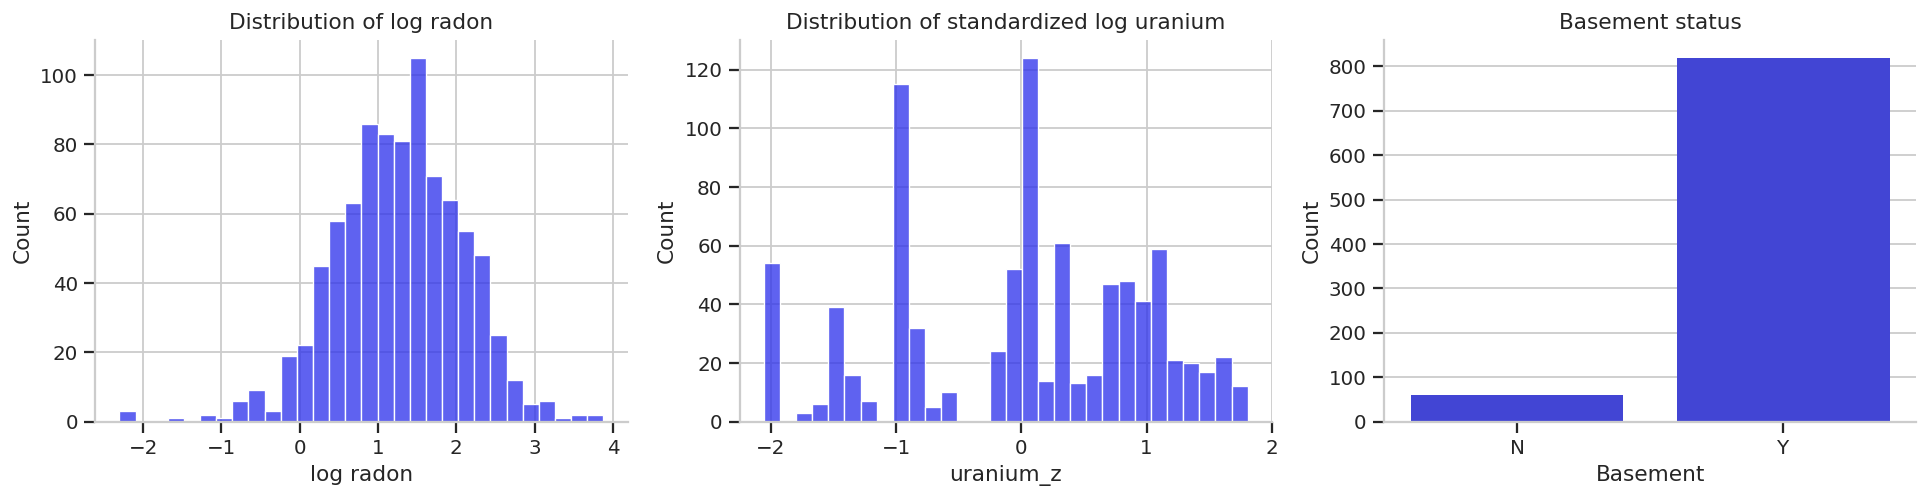

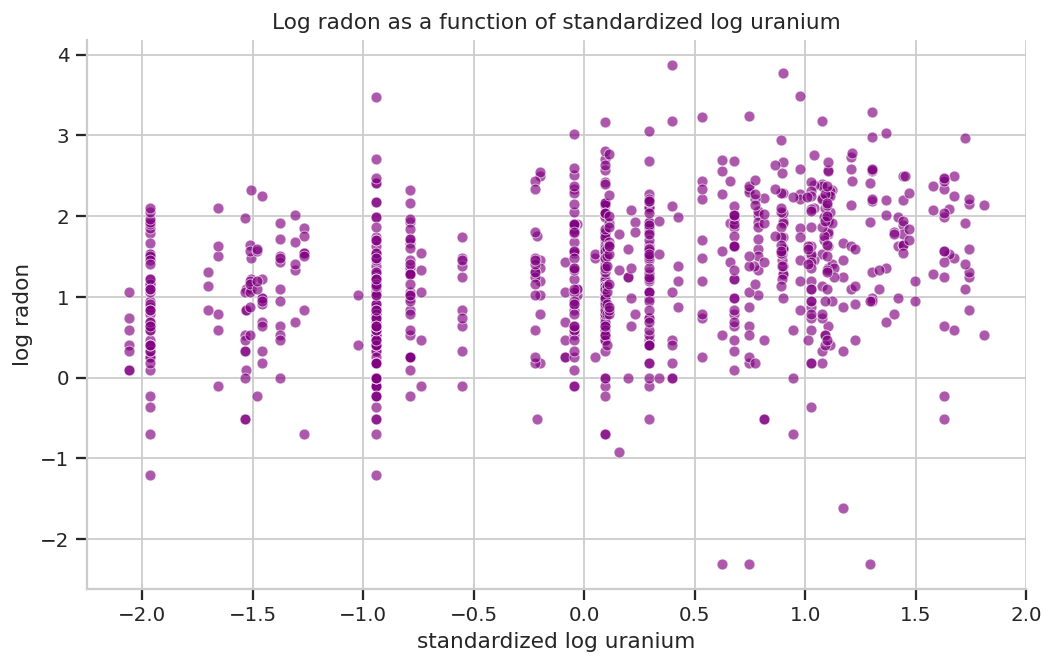

In [ ]:
summary_table = radon[["log_radon", "Uppm", "log_uranium", "uranium_z", "basement_num"]].describe().T
summary_table = summary_table[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
display(summary_table.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(radon["log_radon"], bins=30, ax=axes[0], edgecolor="white")
axes[0].set_title("Distribution of log radon")
axes[0].set_xlabel("log radon")

sns.histplot(radon["uranium_z"], bins=30, ax=axes[1], edgecolor="white")
axes[1].set_title("Distribution of standardized log uranium")
axes[1].set_xlabel("uranium_z")

sns.countplot(data=radon, x="basement", ax=axes[2], order=["N", "Y"])
axes[2].set_title("Basement status")
axes[2].set_xlabel("Basement")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=radon,
    x="uranium_z",
    y="log_radon",
    color="purple",
    alpha=0.65,
)
plt.xlabel("standardized log uranium")
plt.ylabel("log radon")
plt.title("Log radon as a function of standardized log uranium")
plt.show()

## 5. From a Normal model to a linear regression model

A simple Normal model assumes all observations share the same mean:

$$y_i \sim Normal(\mu, \sigma)$$

A linear regression model gives each observation its own mean:

$$y_i \sim Normal(\mu_i, \sigma)$$

$$\mu_i = \beta_0 + \beta_1 x_i$$

Important modeling point:

- The Normal likelihood is about the dependent variable $y$ around $\mu_i$.
- The predictor $x$ is treated as known input to the model.
- We are **not** assuming that $x$ is normally distributed.



## 6. Centering, normalization, and standardization

| Operation | Formula | What it does | Why useful |
|---|---|---|---|
| Centering | $x_c = x - \bar{x}$ | Moves the mean to 0 | Improves intercept interpretation and often helps sampling |
| Normalization | $x_{norm} = \frac{x - \min(x)}{\max(x)-\min(x)}$ | Puts values on a fixed range | Useful when a bounded scale is convenient |
| Standardization | $x_z = \frac{x-\bar{x}}{s_x}$ | Mean 0, SD 1 | Makes slopes comparable and helps choose priors |

In regression, centering is especially important because the intercept becomes the expected value of $y$ when the predictor is at its average value.

In [ ]:
radon["uranium_norm"] = (
    (radon["log_uranium"] - radon["log_uranium"].min())
    / (radon["log_uranium"].max() - radon["log_uranium"].min())
)

transform_summary = pd.DataFrame({
    "variable": ["log_uranium", "uranium_c", "uranium_norm", "uranium_z"],
    "mean": [radon["log_uranium"].mean(), radon["uranium_c"].mean(), radon["uranium_norm"].mean(), radon["uranium_z"].mean()],
    "std": [radon["log_uranium"].std(), radon["uranium_c"].std(), radon["uranium_norm"].std(), radon["uranium_z"].std()],
    "min": [radon["log_uranium"].min(), radon["uranium_c"].min(), radon["uranium_norm"].min(), radon["uranium_z"].min()],
    "max": [radon["log_uranium"].max(), radon["uranium_c"].max(), radon["uranium_norm"].max(), radon["uranium_z"].max()],
})

display(transform_summary.round(3))

,variable,mean,std,min,max
0,log_uranium,-0.131,0.365,-0.882,0.528
1,uranium_c,-0.000,0.365,-0.751,0.659
2,uranium_norm,0.532,0.259,0.000,1.000
3,uranium_z,-0.000,1.000,-2.058,1.807


## 7. Helper functions

In [ ]:
def plot_regression_lines_from_posterior(
    idata,
    x_grid,
    beta0_name="beta0",
    beta1_name="beta_uranium",
    x_original=None,
    y=None,
    x_label="x",
    y_label="y",
    title="Posterior regression lines",
    num_lines=80,
):
    """Plot posterior regression lines for a simple linear regression model."""
    posterior = az.extract(idata, num_samples=num_lines)
    beta0 = posterior[beta0_name].values
    beta1 = posterior[beta1_name].values
    lines = beta0[:, None] + beta1[:, None] * x_grid[None, :]
    mean_line = lines.mean(axis=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    if x_original is not None and y is not None:
        ax.scatter(x_original, y, alpha=0.45, label="Observed data")
    ax.plot(x_grid, lines.T, alpha=0.12)
    ax.plot(x_grid, mean_line, linewidth=2.5, label="Mean posterior line")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    plt.show()


def plot_mu_hdi_from_idata(
    idata,
    x_values,
    y_values,
    x_name="x",
    y_name="y",
    title="Posterior mean and HDI",
    mu_var="mu",
    hdi_prob=HDI_MASS,
):
    """Plot observed data and the HDI of the fitted mean mu_i."""
    order = np.argsort(x_values)
    mu_da = idata.posterior[mu_var]
    mu_hdi = az.hdi(mu_da, hdi_prob=hdi_prob)[mu_var]
    mu_mean = mu_da.mean(dim=("chain", "draw"))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x_values, y_values, alpha=0.45, label="Observed data")
    ax.plot(x_values[order], mu_mean.values[order], linewidth=2.5, label="Mean fitted line")
    ax.fill_between(
        x_values[order],
        mu_hdi.values[order, 0],
        mu_hdi.values[order, 1],
        alpha=0.25,
        label=f"{int(hdi_prob * 100)}% HDI for $\\mu_i$",
    )
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(title)
    ax.legend()
    plt.show()


def print_divergences(idata, model_name):
    """Print the number of divergent transitions in a fitted PyMC model."""

    n_divergences = int(idata.sample_stats["diverging"].sum().values)
    print(f"Number of divergences in {model_name}: {n_divergences}")



def bayesian_r2_from_mu_sigma(idata, mu_var="mu", sigma_var="sigma"):
    """
    Compute Bayesian R^2 from fitted means and residual variance.

    For each posterior draw:
        R^2 = Var(mu_i) / (Var(mu_i) + sigma^2)
    """

    mu = (idata.posterior[mu_var].stack(sample=("chain", "draw")).transpose("sample", ...) .values)

    sigma_values = ( idata.posterior[sigma_var].stack(sample=("chain", "draw")).values)

    explained_variance = np.var(mu, axis=1, ddof=1)
    residual_variance = sigma_values ** 2

    r2 = explained_variance / (explained_variance + residual_variance)
    return np.clip(r2, 0, 1)


def summarize_bayesian_r2(r2_samples, model_name):
    """Return a compact summary table for Bayesian R^2 samples."""

    hdi = az.hdi(r2_samples, hdi_prob=HDI_MASS)
    return pd.DataFrame({
        "model": [model_name],
        "mean_R2": [np.mean(r2_samples)],
        "hdi_low": [hdi[0]],
        "hdi_high": [hdi[1]],
    })

# Part A — Simple Bayesian linear regression in PyMC

We start with a simple Bayesian linear regression model:

$$log\_radon_i \sim Normal(\mu_i, \sigma)$$

$$\mu_i = \beta_0 + \beta_1 uranium_{z,i}$$

The parameter $\sigma$ describes the residual spread of `log_radon` around the fitted regression mean.


## 8. Simple regression model: prior choice

Because `uranium_z` is standardized, a one-unit change means one standard deviation in log uranium. A slope prior such as $Normal(0, 1)$ is therefore written on a standardized effect-size scale.

Observed log radon mean: 1.26
Observed log radon SD: 0.82
Teaching note: these weak priors are scaled using the observed outcome scale.
In a full analysis, priors should be justified from domain knowledge before fitting the model.


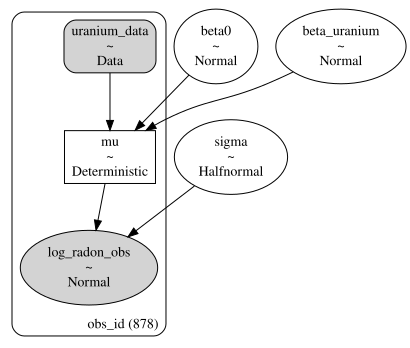

In [ ]:
y = radon["log_radon"].to_numpy()
x_uranium = radon["uranium_z"].to_numpy()
coords = {"obs_id": np.arange(len(radon))}

y_mean = float(np.mean(y))
y_sd = float(np.std(y, ddof=1))

print(f"Observed log radon mean: {y_mean:.2f}")
print(f"Observed log radon SD: {y_sd:.2f}")
print("Teaching note: these weak priors are scaled using the observed outcome scale.")
print("In a full analysis, priors should be justified from domain knowledge before fitting the model.")

with pm.Model(coords=coords) as simple_model:
    # Data
    uranium_data = pm.Data("uranium_data", x_uranium, dims="obs_id")
    # Priors
    beta0 = pm.Normal("beta0", mu=y_mean, sigma=2 * y_sd)
    beta_uranium = pm.Normal("beta_uranium", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=y_sd)
    # Deterministic variable for the regression fomula
    mu = pm.Deterministic("mu", beta0 + beta_uranium * uranium_data, dims="obs_id")
    # Likelihood
    log_radon_obs = pm.Normal("log_radon_obs", mu=mu, sigma=sigma, observed=y, dims="obs_id")

    # Sampling Prior predictive (can be done outside the model)
    idata_simple_prior = pm.sample_prior_predictive(samples=1000, random_seed=RANDOM_SEED)

pm.model_to_graphviz(simple_model)

## 9. Prior predictive check

The prior predictive check asks whether the model generates plausible log-radon values before seeing the data. This checks **model coherence**, not model fit.

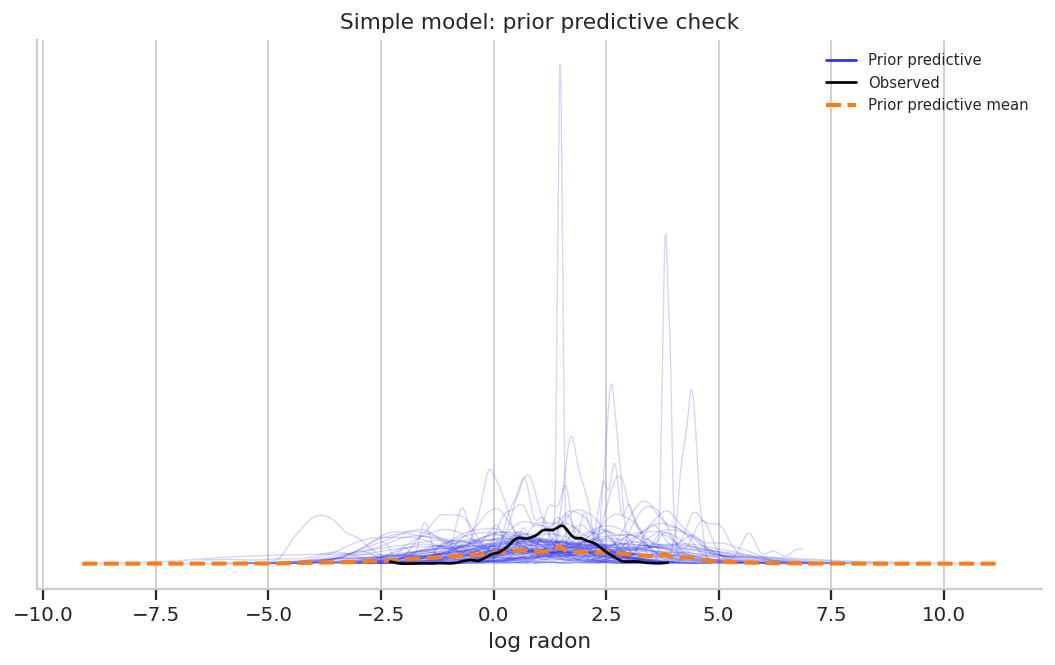

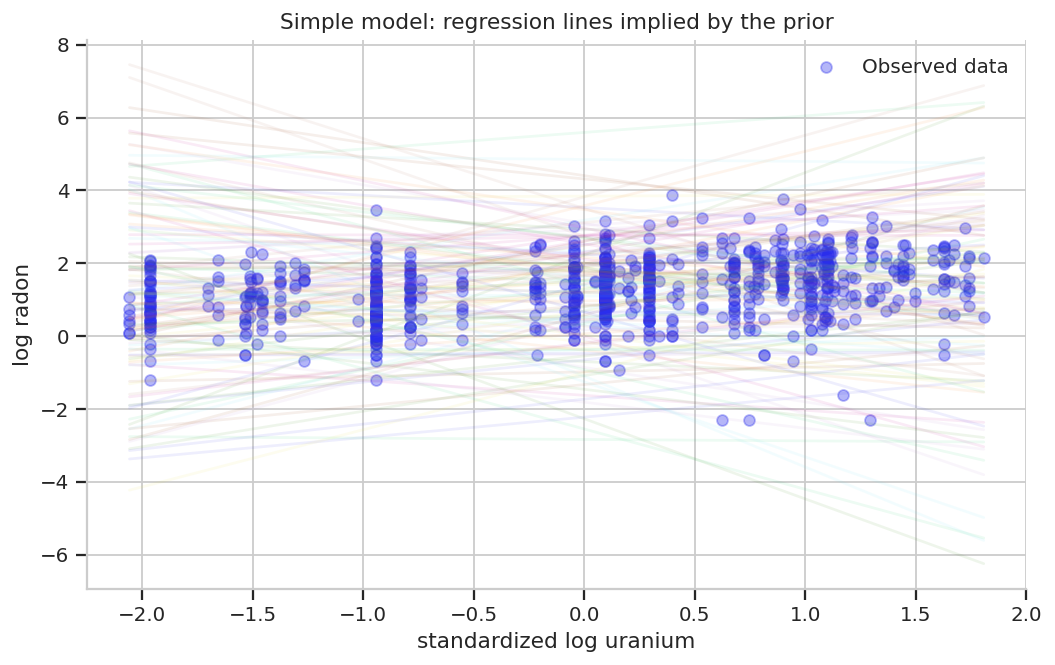

In [ ]:
az.plot_ppc(idata_simple_prior, group="prior", observed=True, num_pp_samples=100)
plt.title("Simple model: prior predictive check")
plt.xlabel("log radon")
plt.show()

# Extract prior samples directly from the prior group.
prior_beta0 = (idata_simple_prior.prior["beta0"].stack(sample=("chain", "draw")).values)
prior_beta_uranium = (idata_simple_prior.prior["beta_uranium"].stack(sample=("chain", "draw")).values)

# Choose a subset of prior draws to plot.
n_prior_lines = 120
rng_prior = np.random.default_rng(RANDOM_SEED)

selected_draws = rng_prior.choice(len(prior_beta0), size=n_prior_lines, replace=False)

x_grid = np.linspace(x_uranium.min(), x_uranium.max(), 100)
prior_lines = (prior_beta0[selected_draws, None] + prior_beta_uranium[selected_draws, None] * x_grid[None, :])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_uranium, y, alpha=0.35, label="Observed data")
ax.plot(x_grid, prior_lines.T, alpha=0.08)
ax.set_xlabel("standardized log uranium")
ax.set_ylabel("log radon")
ax.set_title("Simple model: regression lines implied by the prior")
ax.legend()

plt.show()

## 10. Sampling and diagnostics

Diagnostics ask whether we approximately sampled the posterior distribution of this model. They do **not** tell us whether the model is scientifically correct or whether it fits the data well.

In [ ]:
with simple_model:
    idata_simple = pm.sample(
        draws=1000,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

print_divergences(idata_simple, "simple model")

# Add the prior and prior predictive groups to the same InferenceData object,
idata_simple.extend(idata_simple_prior)

idata_simple

Output()

Number of divergences in simple model: 0


Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

/tmp/ipykernel_2275/3923617030.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


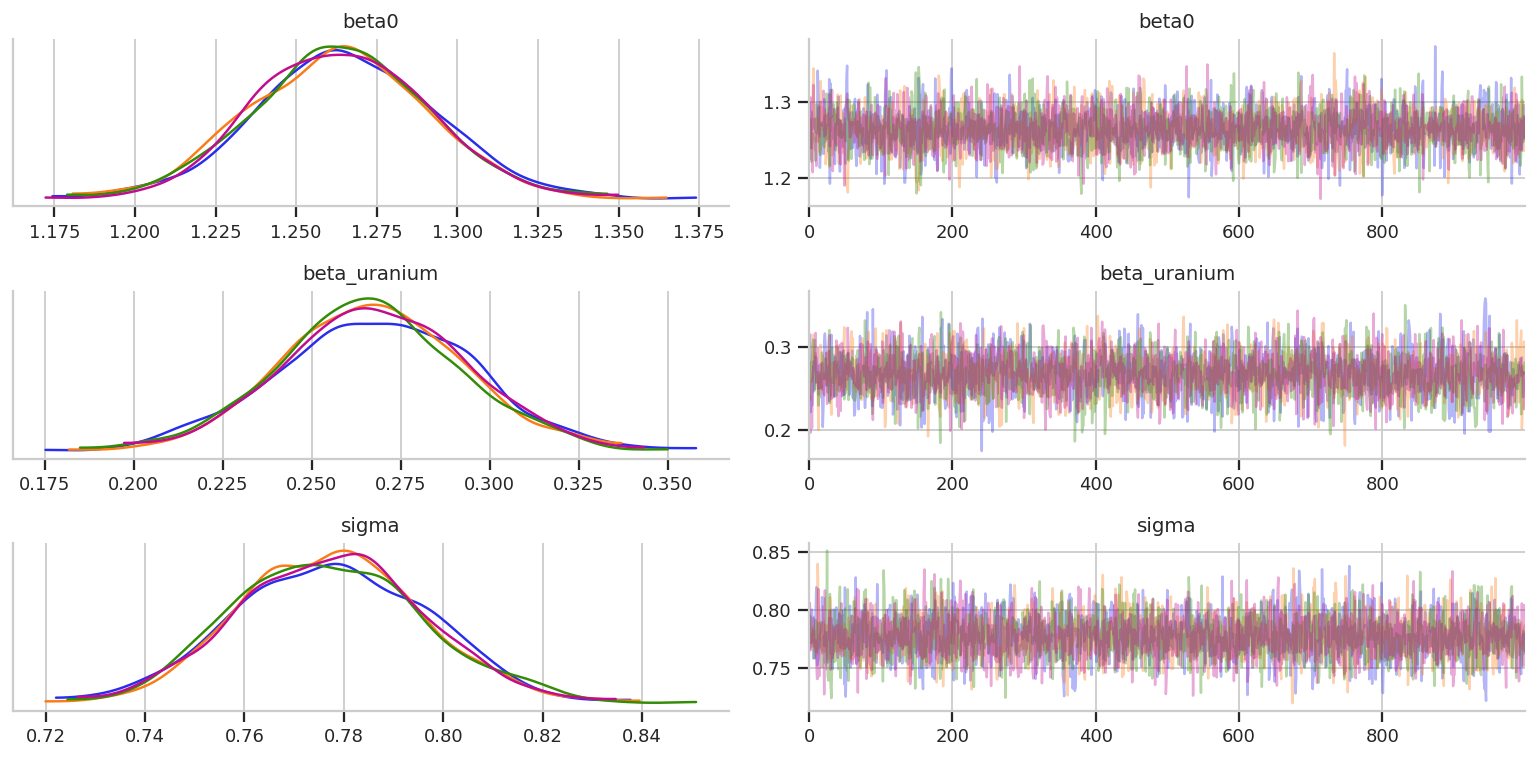

In [ ]:
az.plot_trace(idata_simple, var_names=["beta0", "beta_uranium", "sigma"], compact=False)
plt.tight_layout()
plt.show()

In [ ]:
az.summary(idata_simple, var_names=["beta0", "beta_uranium", "sigma"], kind="diagnostics").round(2)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.0,0.0,4324.0,2784.0,1.0
beta_uranium,0.0,0.0,3817.0,3079.0,1.0
sigma,0.0,0.0,4700.0,2764.0,1.0


## 11. Posterior interpretation

The slope `beta_uranium` is the expected change in `log_radon` for a one-standard-deviation increase in log uranium. Because this is Bayesian regression, the slope is a posterior distribution, not one number.

/tmp/ipykernel_2275/2471477471.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


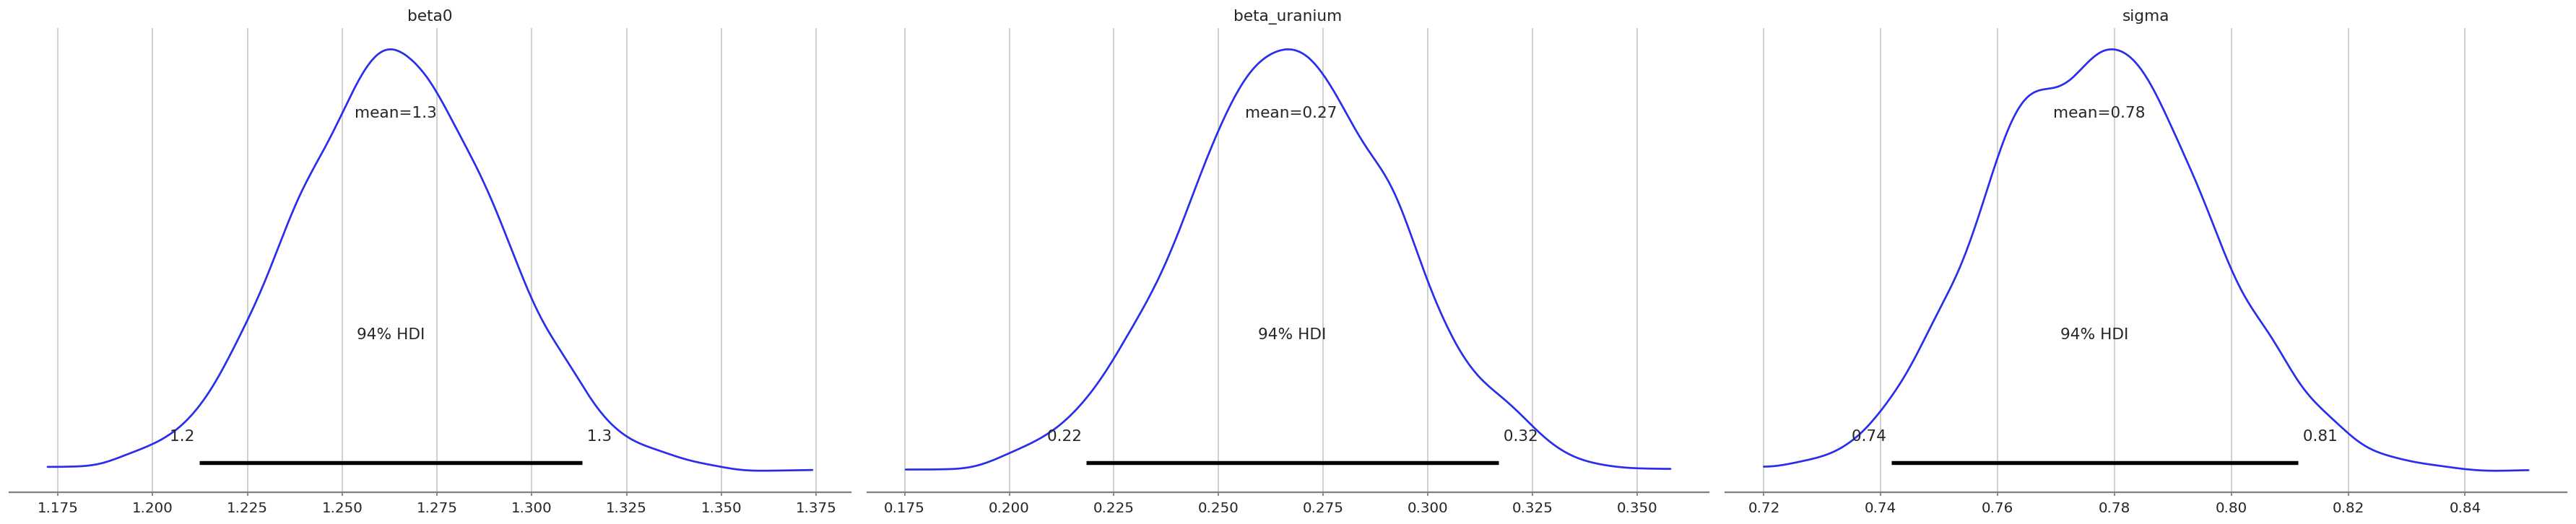

In [ ]:
az.plot_posterior(idata_simple, var_names=["beta0", "beta_uranium", "sigma"], hdi_prob=HDI_MASS)
plt.tight_layout()
plt.show()

In [ ]:
az.summary(idata_simple, var_names=["beta0", "beta_uranium", "sigma"], hdi_prob=HDI_MASS, kind="stats").round(3)

,mean,sd,hdi_3%,hdi_97%
beta0,1.264,0.027,1.212,1.313
beta_uranium,0.267,0.026,0.218,0.317
sigma,0.777,0.019,0.742,0.811


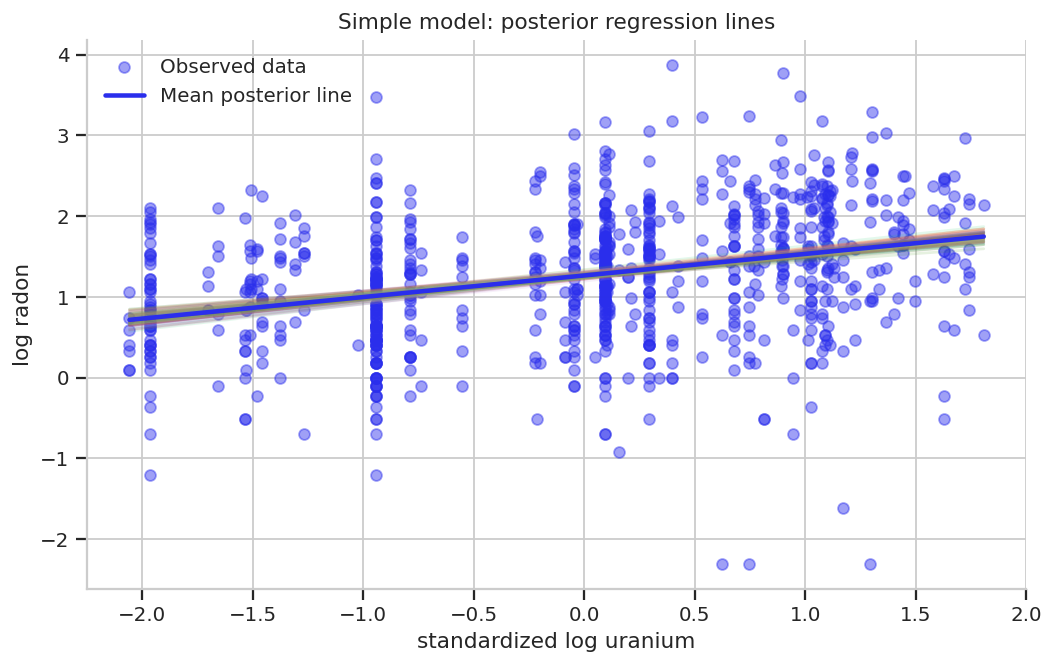

In [ ]:
plot_regression_lines_from_posterior(
    idata_simple,
    x_grid=x_grid,
    beta0_name="beta0",
    beta1_name="beta_uranium",
    x_original=x_uranium,
    y=y,
    x_label="standardized log uranium",
    y_label="log radon",
    title="Simple model: posterior regression lines",
    num_lines=100,
)

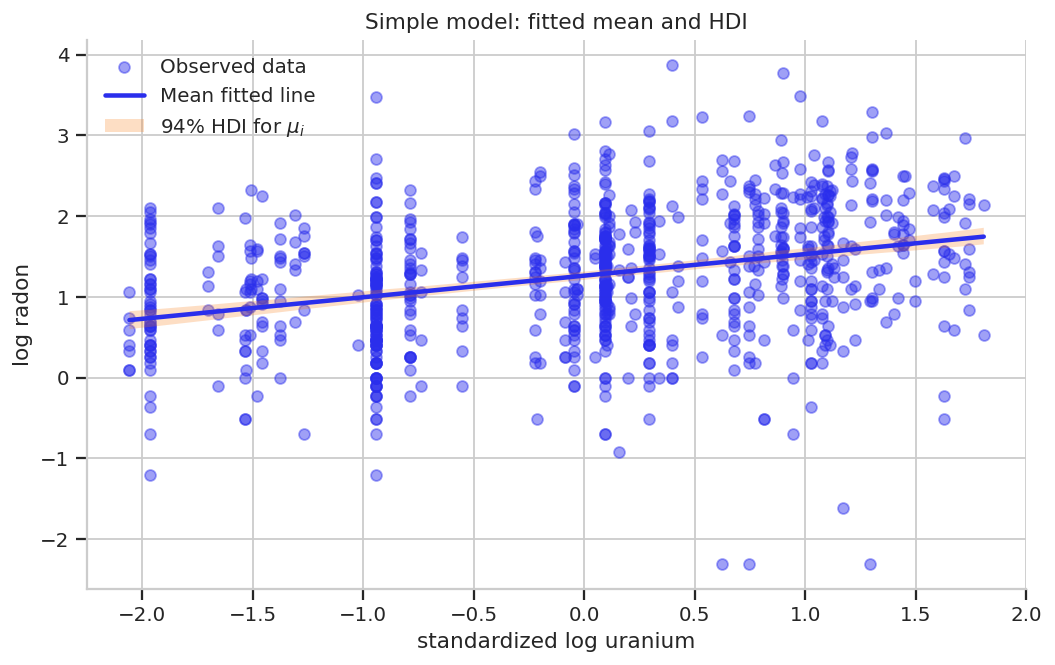

In [ ]:
plot_mu_hdi_from_idata(
    idata_simple,
    x_values=x_uranium,
    y_values=y,
    x_name="standardized log uranium",
    y_name="log radon",
    title="Simple model: fitted mean and HDI",
)

## 12. Centering and sampling geometry

To see why centering can matter, we fit a similar simple model using the uncentered `log_uranium` predictor. The intercept now refers to `log_uranium = 0`, not to the center of the data. Also note that the slope prior is now written on a different predictor scale, so this is a teaching demonstration of geometry and interpretation rather than a perfect one-to-one prior comparison.

In [ ]:
x_uncentered = radon["log_uranium"].to_numpy()

with pm.Model(coords=coords) as uncentered_model:
    uranium_uncentered_data = pm.Data("uranium_uncentered_data", x_uncentered, dims="obs_id")

    beta0 = pm.Normal("beta0", mu=y_mean, sigma=2 * y_sd)
    beta_uranium = pm.Normal("beta_uranium", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=y_sd)
    mu = pm.Deterministic("mu", beta0 + beta_uranium * uranium_uncentered_data, dims="obs_id")
    log_radon_obs = pm.Normal("log_radon_obs", mu=mu, sigma=sigma, observed=y, dims="obs_id")

    idata_uncentered = pm.sample(draws=1000, chains=4,
        target_accept=0.9, random_seed=RANDOM_SEED, return_inferencedata=True,)

print_divergences(idata_uncentered, "uncentered model")

Output()

Number of divergences in uncentered model: 0


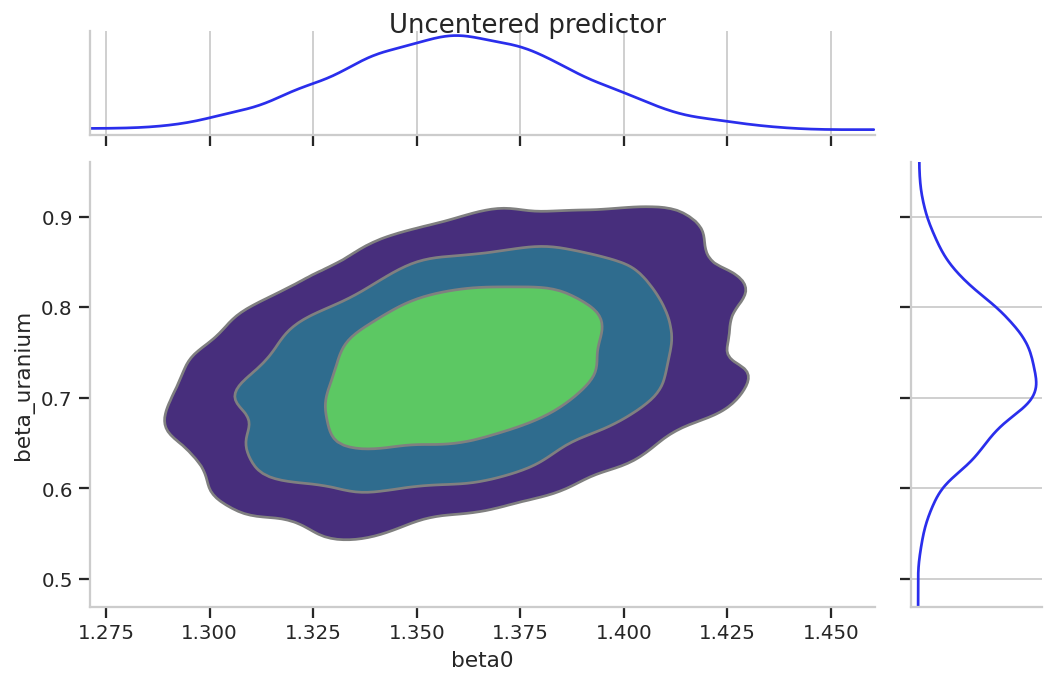

In [ ]:
az.plot_pair(
    idata_uncentered,
    var_names=["beta0", "beta_uranium"],
    kind="kde",
    marginals=True
)

plt.suptitle("Uncentered predictor", y=1.02)
plt.show()

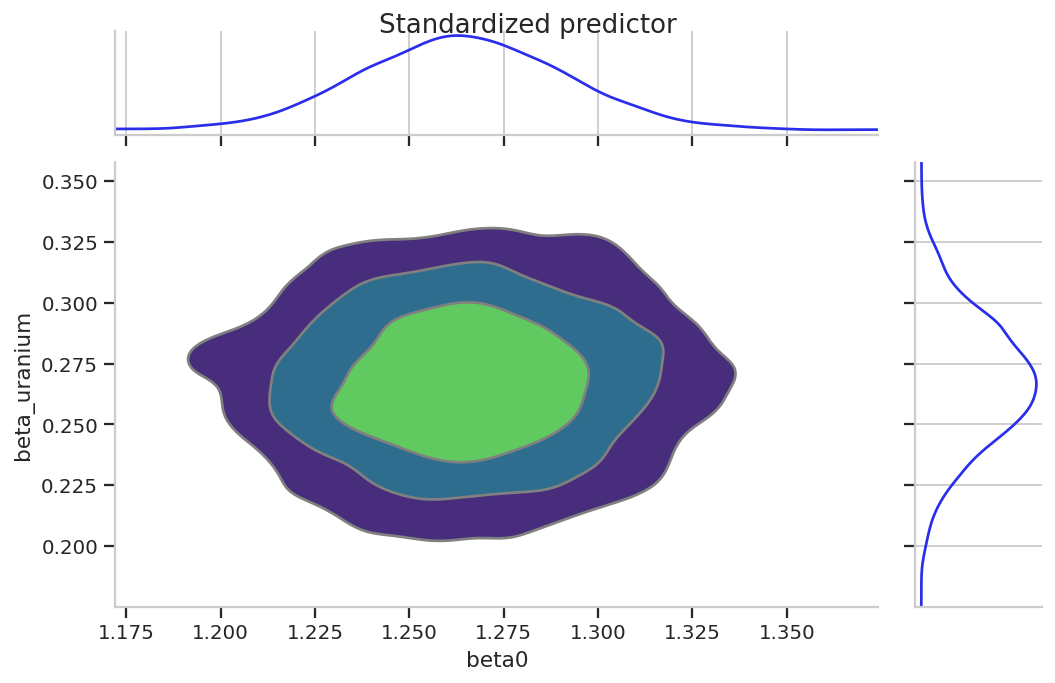

In [ ]:
az.plot_pair(
    idata_simple,
    var_names=["beta0", "beta_uranium"],
    kind="kde",
    marginals=True
)

plt.suptitle("Standardized predictor", y=1.02)
plt.show()

## 13. Posterior predictive check

Posterior predictive sampling asks: If this fitted model were true, what new datasets would it generate?

In [ ]:
with simple_model:
    idata_simple = pm.sample_posterior_predictive(
        idata_simple,
        var_names=["log_radon_obs"],
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
    )

Output()

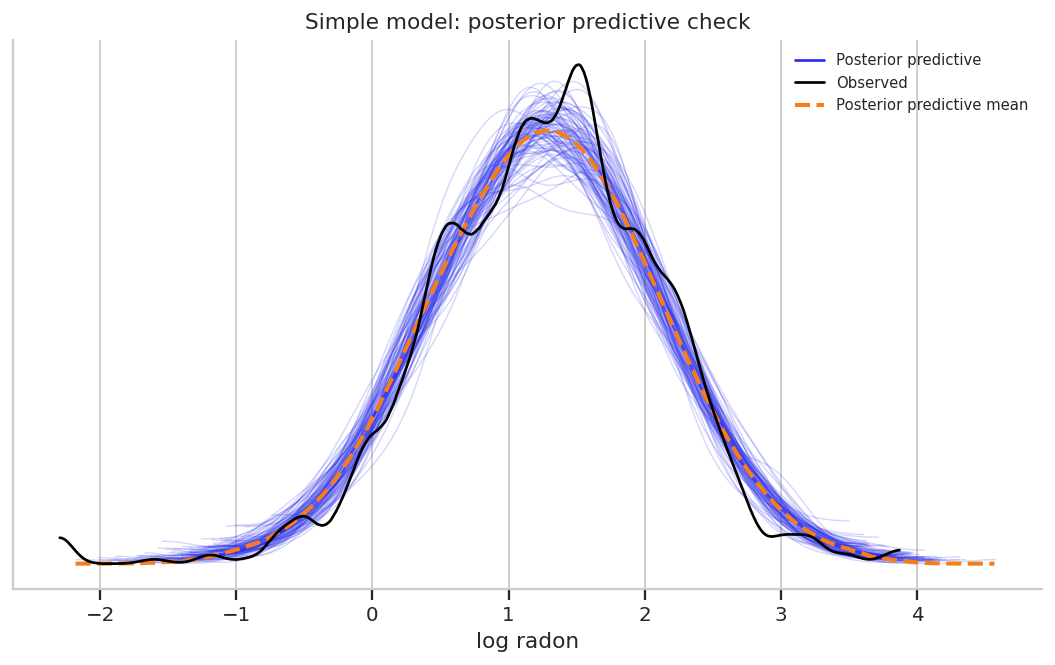

In [ ]:
az.plot_ppc(idata_simple, group="posterior", observed=True, num_pp_samples=100)
plt.title("Simple model: posterior predictive check")
plt.xlabel("log radon")
plt.show()

## 14. Bayesian p-value plots

The students have already learned Bayesian p-values. Here we only use them as an additional model-checking visualization.

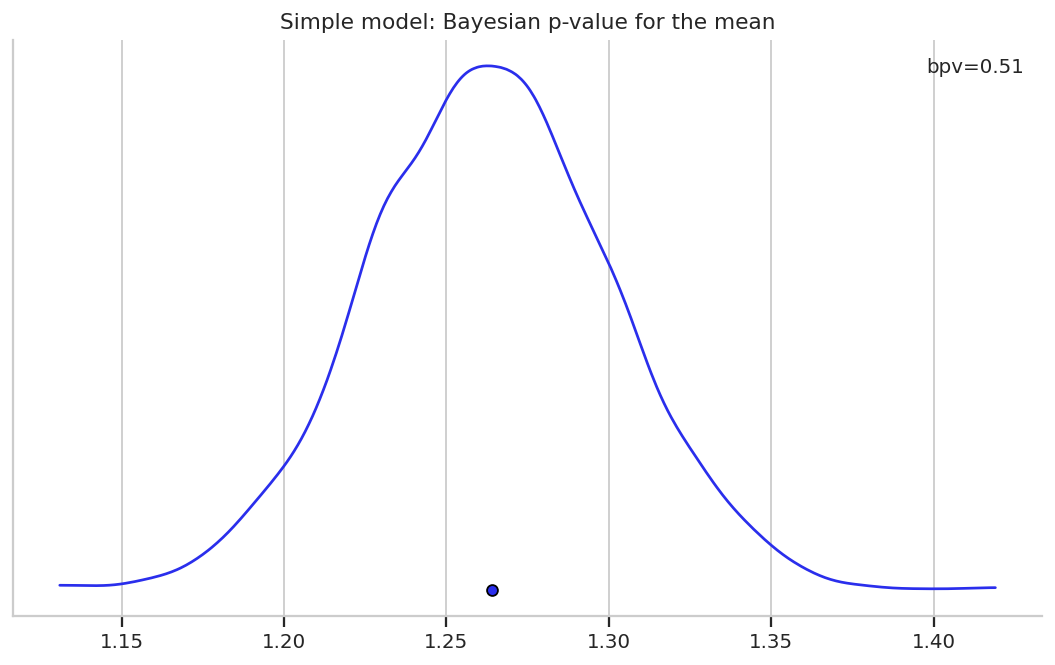

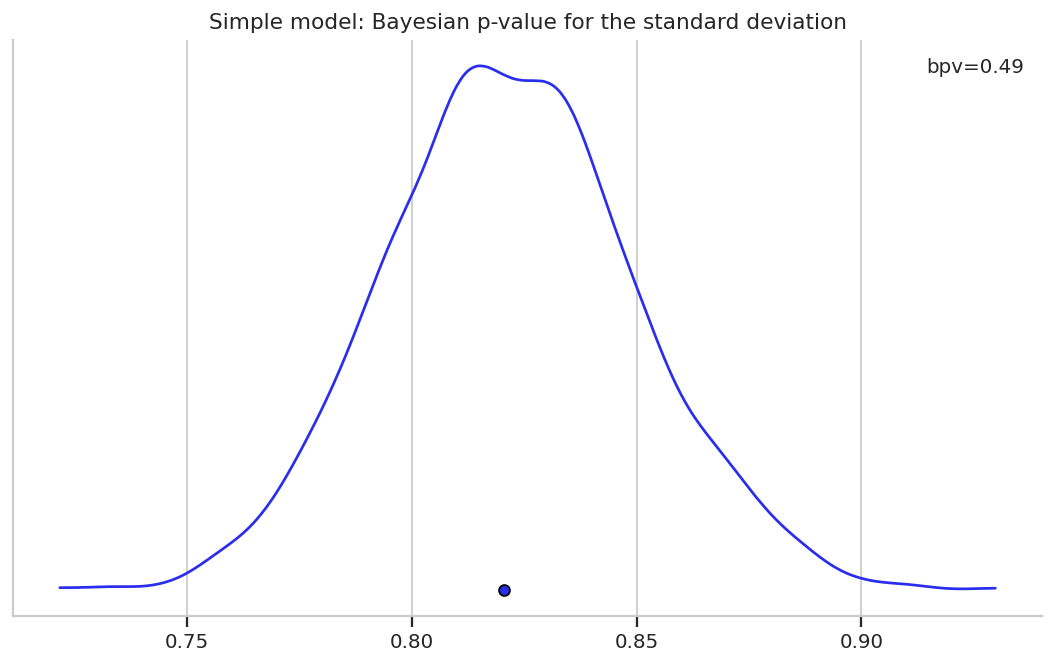

In [ ]:
try:
    az.plot_bpv(idata_simple, kind="t_stat", t_stat="mean")
    plt.title("Simple model: Bayesian p-value for the mean")
    plt.show()

    az.plot_bpv(idata_simple, kind="t_stat", t_stat="std")
    plt.title("Simple model: Bayesian p-value for the standard deviation")
    plt.show()
except Exception as error:
    print("Bayesian p-value plots were skipped because of an ArviZ version/API issue:")
    print(error)

# Part B — Multiple regression

Now we include two predictors:

$$log\_radon_i \sim Normal(\mu_i, \sigma)$$

$$\mu_i = beta_0 + beta_1 uranium_{z,i} + beta_2 basement_{num,i}$$

Each slope is interpreted while holding the other predictor fixed.



## 15. Predictor relationship and colored scatter plot

,uranium_z,basement_num,log_radon
uranium_z,1.000,0.057,0.326
basement_num,0.057,1.000,0.159
log_radon,0.326,0.159,1.000


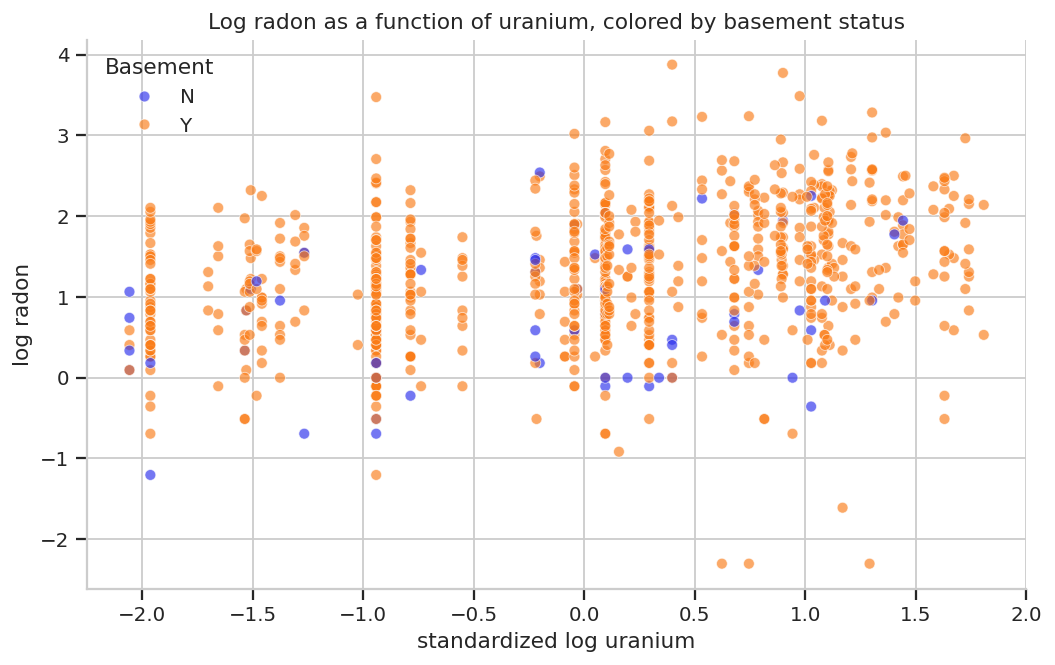

In [ ]:
# We'll use `basement_num` consistently throughout the PyMC, Bambi, and OLS models.
display(radon[["uranium_z", "basement_num", "log_radon"]].corr().round(3))

plt.figure(figsize=(8, 5))
sns.scatterplot(data=radon, x="uranium_z", y="log_radon", hue="basement", alpha=0.65)
plt.xlabel("standardized log uranium")
plt.ylabel("log radon")
plt.title("Log radon as a function of uranium, colored by basement status")
plt.legend(title="Basement")
plt.show()

## 16. Multiple regression model in PyMC

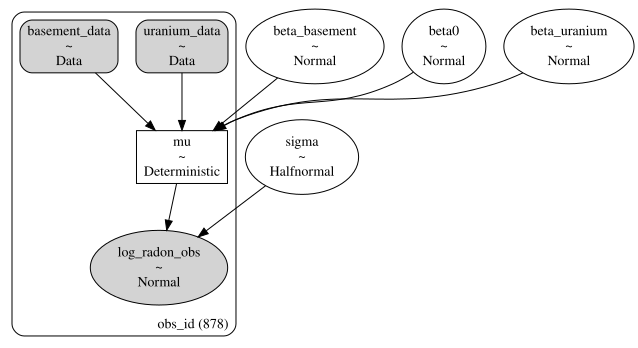

In [ ]:
x_basement = radon["basement_num"].to_numpy()

with pm.Model(coords=coords) as multiple_model:
    uranium_data = pm.Data("uranium_data", x_uranium, dims="obs_id")
    basement_data = pm.Data("basement_data", x_basement, dims="obs_id")

    beta0 = pm.Normal("beta0", mu=y_mean, sigma=2 * y_sd)
    beta_uranium = pm.Normal("beta_uranium", mu=0, sigma=1)
    beta_basement = pm.Normal("beta_basement", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=y_sd)

    mu = pm.Deterministic("mu", beta0 + beta_uranium * uranium_data + beta_basement * basement_data, dims="obs_id")
    log_radon_obs = pm.Normal("log_radon_obs", mu=mu, sigma=sigma, observed=y, dims="obs_id")

    idata_multiple_prior = pm.sample_prior_predictive(samples=1000, random_seed=RANDOM_SEED)

pm.model_to_graphviz(multiple_model)

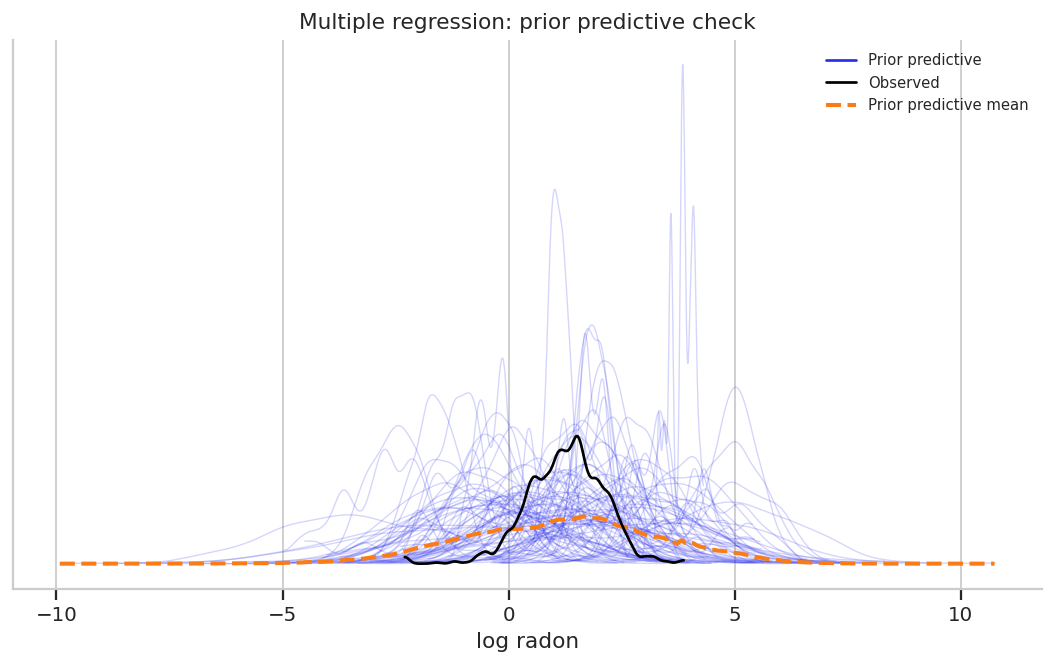

In [ ]:
az.plot_ppc(idata_multiple_prior, group="prior", observed=True, num_pp_samples=100)
plt.title("Multiple regression: prior predictive check")
plt.xlabel("log radon")
plt.show()

In [ ]:
with multiple_model:
    idata_multiple = pm.sample(
        draws=1000,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

print_divergences(idata_multiple, "multiple regression model")

Output()

Number of divergences in multiple regression model: 0


In [ ]:
# Add the prior and prior predictive groups to the same InferenceData object,
idata_multiple.extend(idata_multiple_prior)

with multiple_model:
    idata_multiple = pm.sample_posterior_predictive(
        idata_multiple,
        var_names=["log_radon_obs"],
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
    )

idata_multiple

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

/tmp/ipykernel_2275/3072606517.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


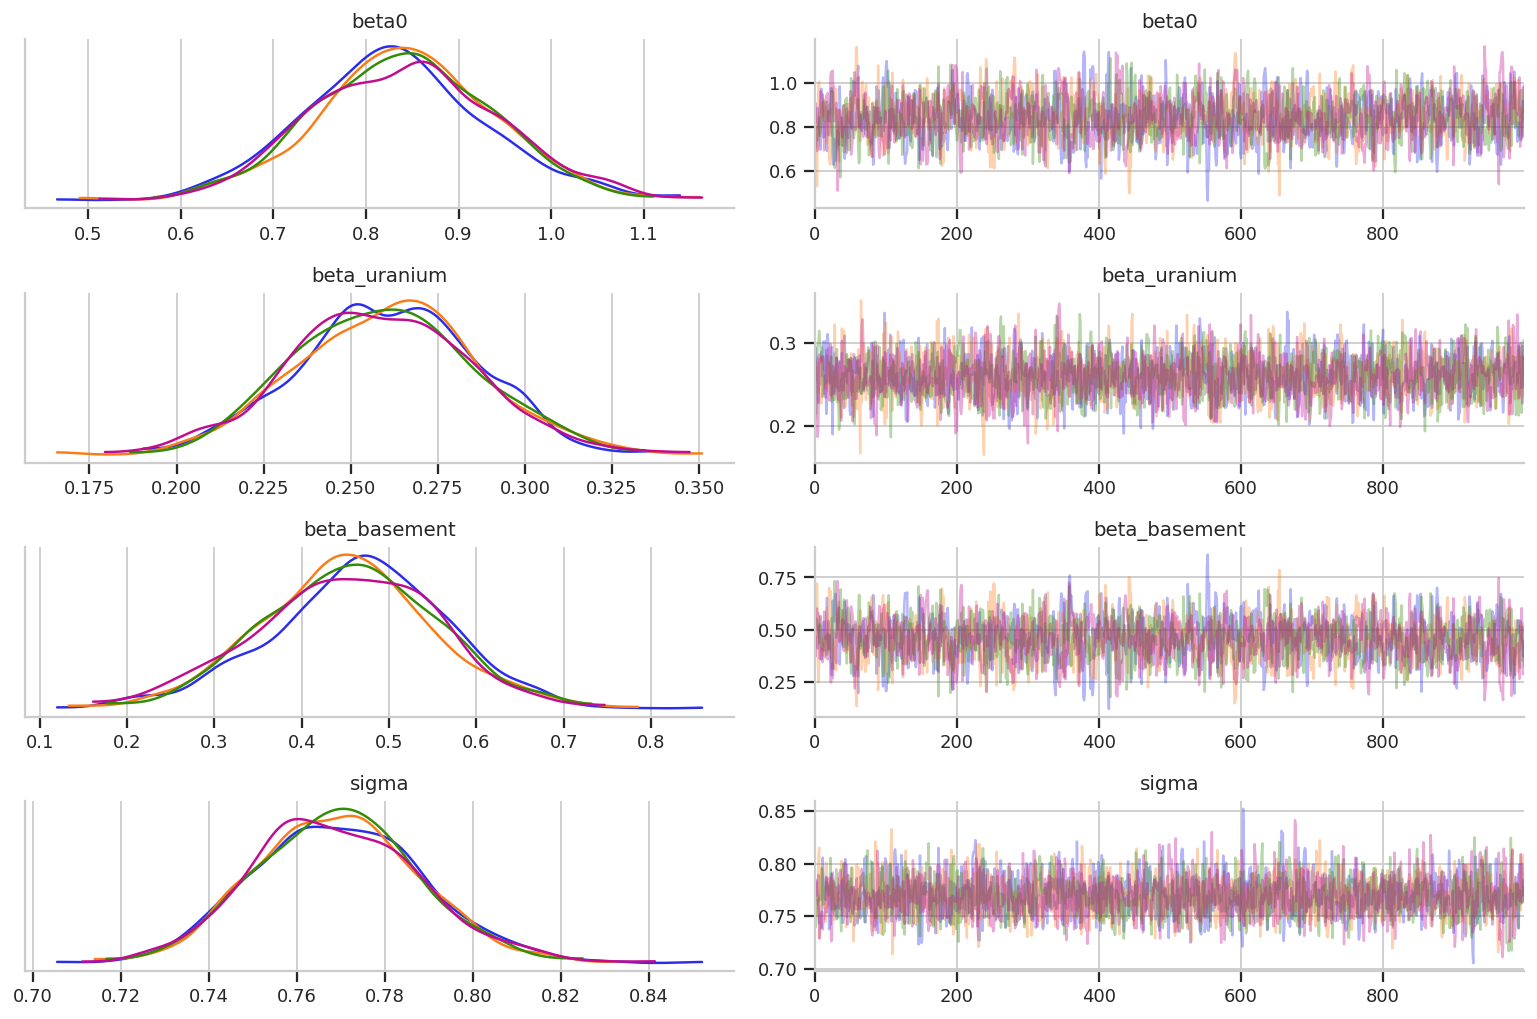

In [ ]:
az.plot_trace(idata_multiple, var_names=["beta0", "beta_uranium", "beta_basement", "sigma"], compact=False)
plt.tight_layout()
plt.show()

In [ ]:
az.summary(
    idata_multiple,
    var_names=["beta0", "beta_uranium", "beta_basement", "sigma"],
    kind="diagnostics"
).round(2)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.0,0.0,1708.0,1827.0,1.0
beta_uranium,0.0,0.0,2715.0,2234.0,1.0
beta_basement,0.0,0.0,1660.0,1943.0,1.0
sigma,0.0,0.0,3035.0,2386.0,1.0


In [ ]:
az.summary(
    idata_multiple,
    var_names=["beta0", "beta_uranium", "beta_basement", "sigma"],
    hdi_prob=HDI_MASS,
    kind="stats"
).round(3)

,mean,sd,hdi_3%,hdi_97%
beta0,0.840,0.098,0.651,1.026
beta_uranium,0.260,0.026,0.212,0.309
beta_basement,0.456,0.101,0.256,0.641
sigma,0.769,0.019,0.735,0.805


## 17. Posterior interpretation for multiple regression

/tmp/ipykernel_2275/1889676403.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


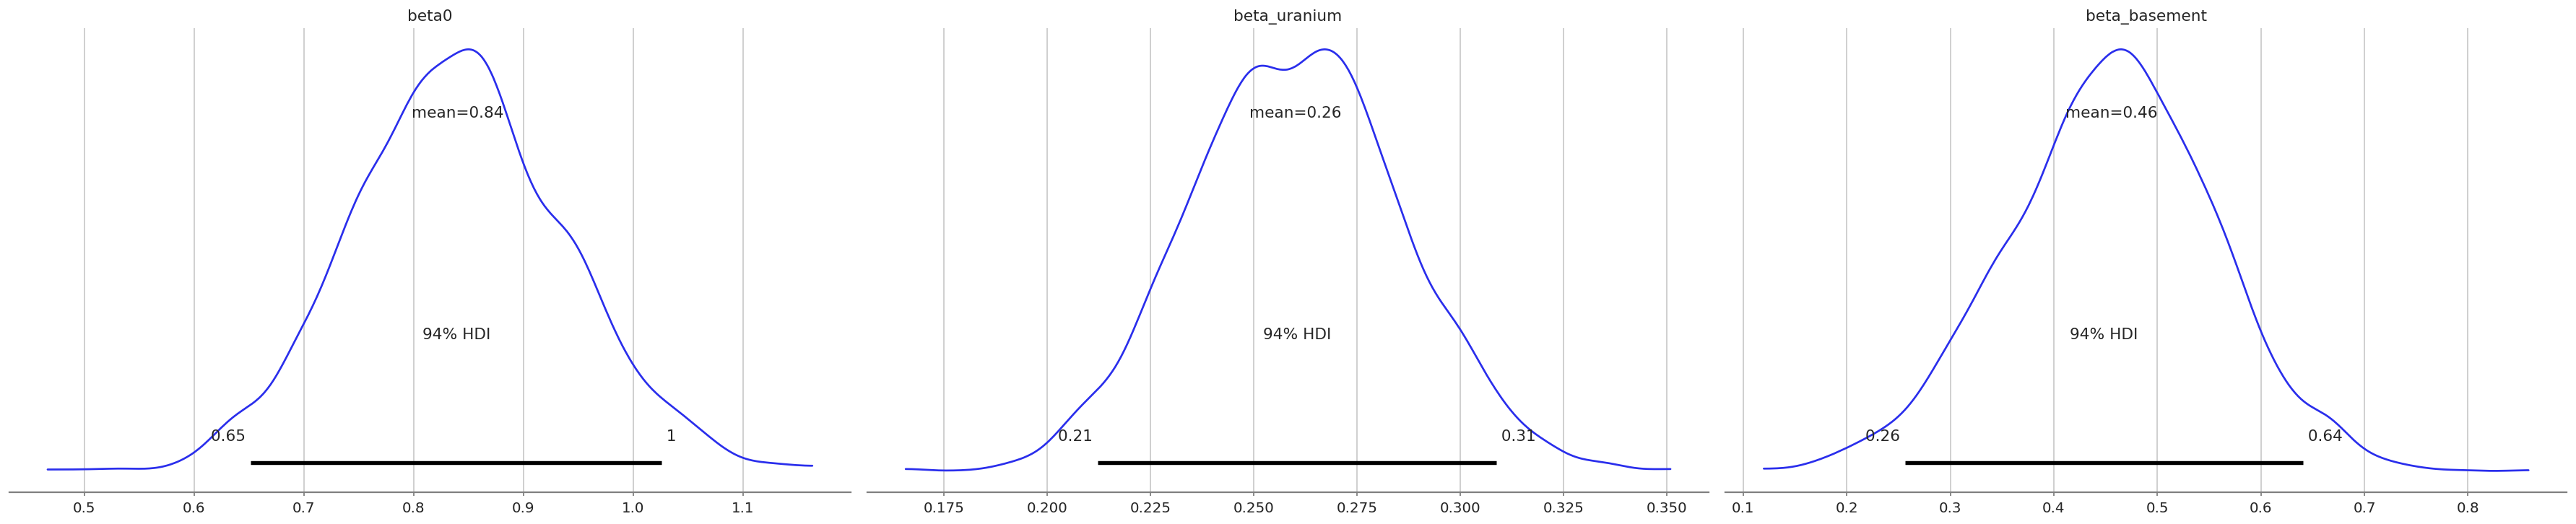

In [ ]:
az.plot_posterior(idata_multiple, var_names=["beta0", "beta_uranium", "beta_basement"], hdi_prob=HDI_MASS)
plt.tight_layout()
plt.show()

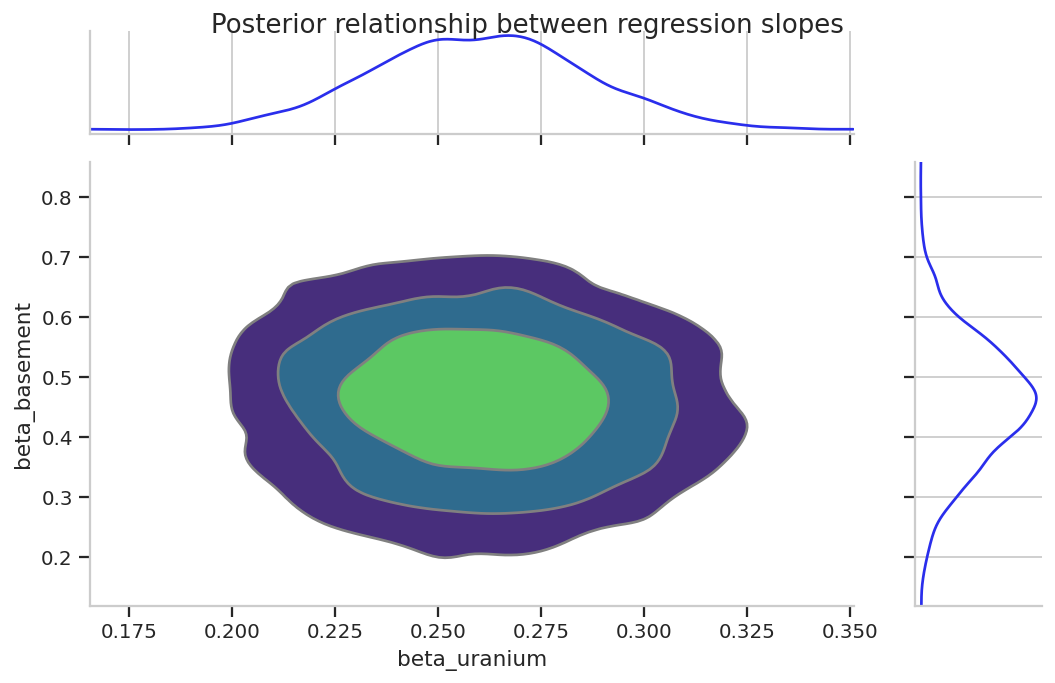

In [ ]:
az.plot_pair(idata_multiple, var_names=["beta_uranium", "beta_basement"], kind="kde", marginals=True)
plt.suptitle("Posterior relationship between regression slopes", y=1.02)
plt.show()

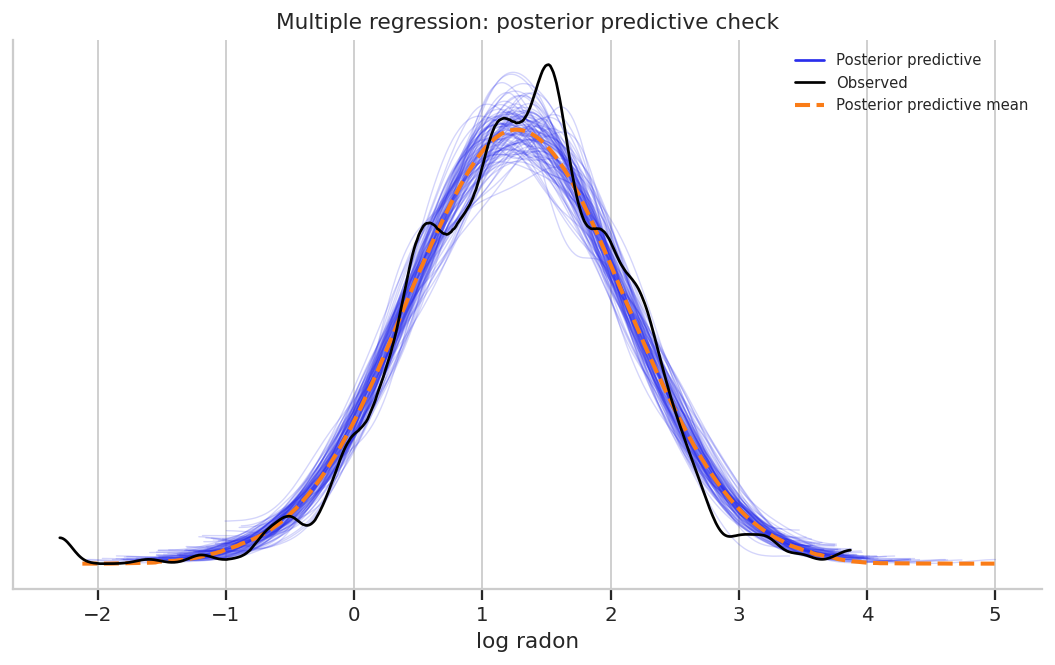

In [ ]:
az.plot_ppc(idata_multiple, group="posterior", observed=True, num_pp_samples=100)
plt.title("Multiple regression: posterior predictive check")
plt.xlabel("log radon")
plt.show()

## 18. Conditional regression lines

In multiple regression, the model gives different expected values for different basement statuses.

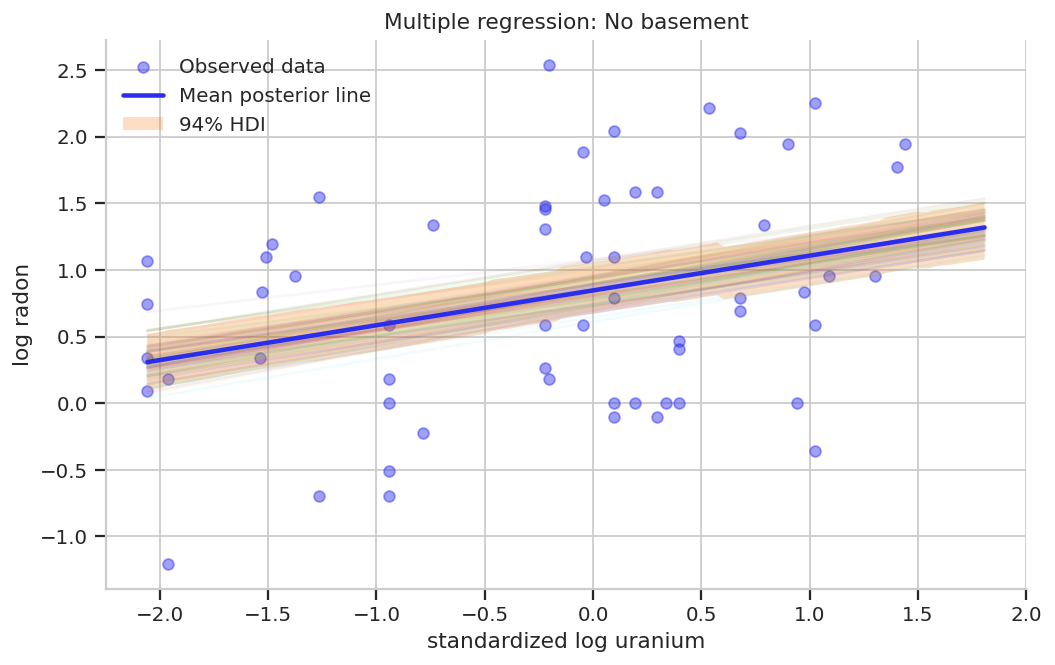

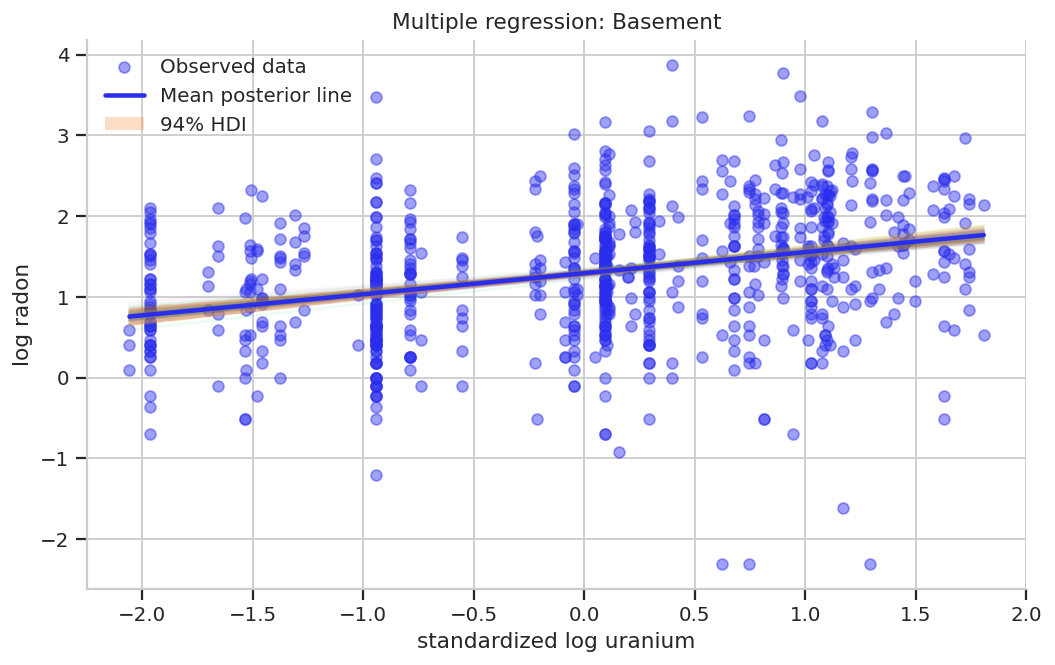

In [ ]:
posterior = az.extract(idata_multiple, num_samples=1000)

x_grid = np.linspace(x_uranium.min(), x_uranium.max(), 120)
basement_num_N = 0
basement_num_Y = 1

mu_N = posterior["beta0"].values[:, None] + posterior["beta_uranium"].values[:, None] * x_grid[None, :] + posterior["beta_basement"].values[:, None] * basement_num_N
mu_Y = posterior["beta0"].values[:, None] + posterior["beta_uranium"].values[:, None] * x_grid[None, :] + posterior["beta_basement"].values[:, None] * basement_num_Y

for label, mu_lines, basement_value in [("No basement", mu_N, "N"), ("Basement", mu_Y, "Y")]:
    plt.figure(figsize=(8, 5))
    subset = radon[radon["basement"] == basement_value]
    plt.scatter(subset["uranium_z"], subset["log_radon"], alpha=0.45, label="Observed data")
    plt.plot(x_grid, mu_lines[:80].T, alpha=0.08)
    plt.plot(x_grid, mu_lines.mean(axis=0), linewidth=2.5, label="Mean posterior line")
    hdi = az.hdi(mu_lines, hdi_prob=HDI_MASS)
    plt.fill_between(x_grid, hdi[:, 0], hdi[:, 1], alpha=0.25, label=f"{int(HDI_MASS*100)}% HDI")
    plt.xlabel("standardized log uranium")
    plt.ylabel("log radon")
    plt.title(f"Multiple regression: {label}")
    plt.legend()
    plt.show()

## 19. Bayesian $R^2$

In Bayesian regression, each posterior draw gives a different fitted mean vector $\mu_i$. Therefore Bayesian $R^2$ is a posterior distribution.

Here we use the standard Bayesian regression version:

$$R^2 = \frac{Var(\mu_i)}{Var(\mu_i) + \sigma^2}$$

,model,mean_R2,hdi_low,hdi_high
0,simple: uranium,0.106,0.073,0.144
1,multiple: uranium + basement,0.126,0.091,0.165


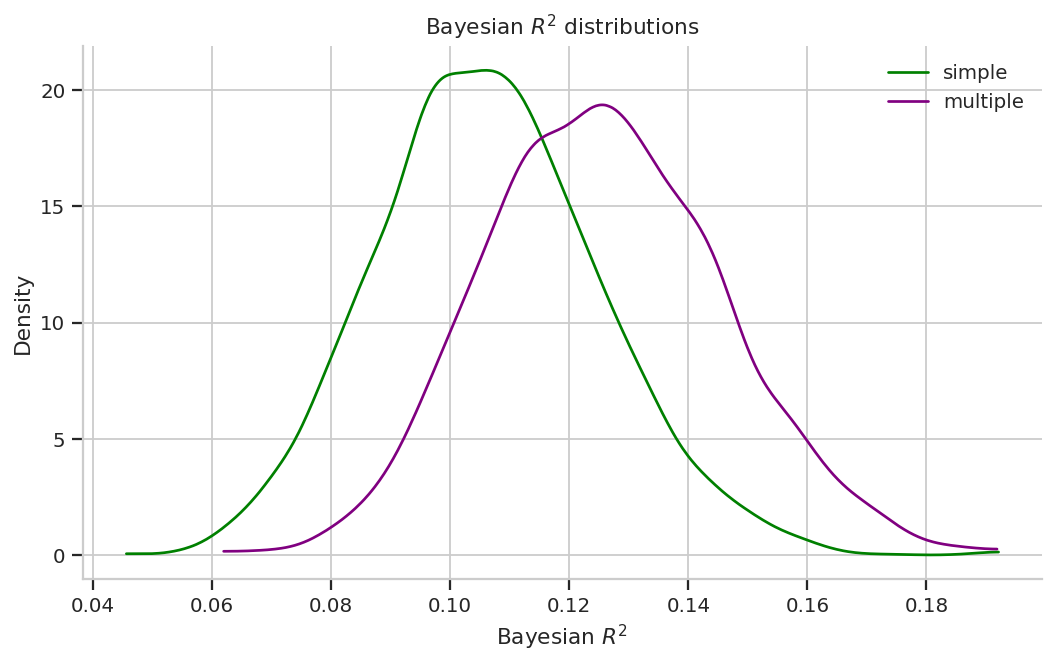

In [ ]:
r2_simple = bayesian_r2_from_mu_sigma(idata_simple, mu_var="mu", sigma_var="sigma")
r2_multiple = bayesian_r2_from_mu_sigma(idata_multiple, mu_var="mu", sigma_var="sigma")

r2_summary = pd.concat([
    summarize_bayesian_r2(r2_simple, "simple: uranium"),
    summarize_bayesian_r2(r2_multiple, "multiple: uranium + basement"),
], ignore_index=True)

display(r2_summary.round(3))

plt.figure(figsize=(8, 5))
az.plot_dist(r2_simple, label="simple", kind="kde", color='green')
az.plot_dist(r2_multiple, label="multiple", kind="kde", color='purple')
plt.xlabel(r"Bayesian $R^2$")
plt.ylabel("Density")
plt.title(r"Bayesian $R^2$ distributions")
plt.legend()
plt.show()

# Part C — Bambi

Bambi is a high-level Bayesian model-building interface built on top of PyMC.

The main advantage is formula syntax:

```python
bmb.Model("log_radon ~ uranium_z + basement_num", data=radon)
```

Bambi is useful for standard regression models because it lets us write the model using formula syntax instead of defining every PyMC variable manually.

Coding note: we use `basement_num` consistently in PyMC, Bambi, and OLS. Here 0 means no basement and 1 means basement, so the intercept refers to houses without a basement when `uranium_z = 0`.


## 20. Simple regression with Bambi

Bambi automatically defines default priors. The important point here is the modeling logic: Bambi uses the formula and the data scale to define default weakly informative priors. The model formula is the same regression structure used above, but Bambi builds the PyMC model automatically.

In [ ]:
# Create the model using Bambi
bambi_simple_model = bmb.Model("log_radon ~ uranium_z", data=radon)
print(bambi_simple_model)

       Formula: log_radon ~ uranium_z
        Family: gaussian
          Link: mu = identity
  Observations: 878
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.2641, sigma: 2.0511)
            uranium_z ~ Normal(mu: 0.0, sigma: 2.0523)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.8204)


In [ ]:
# Sample
idata_bambi_simple = bambi_simple_model.fit(
    draws=1000,
    chains=4,
    random_seed=RANDOM_SEED,
    target_accept=0.9,
)

print_divergences(idata_bambi_simple, "Bambi simple model")

Output()

Number of divergences in Bambi simple model: 0


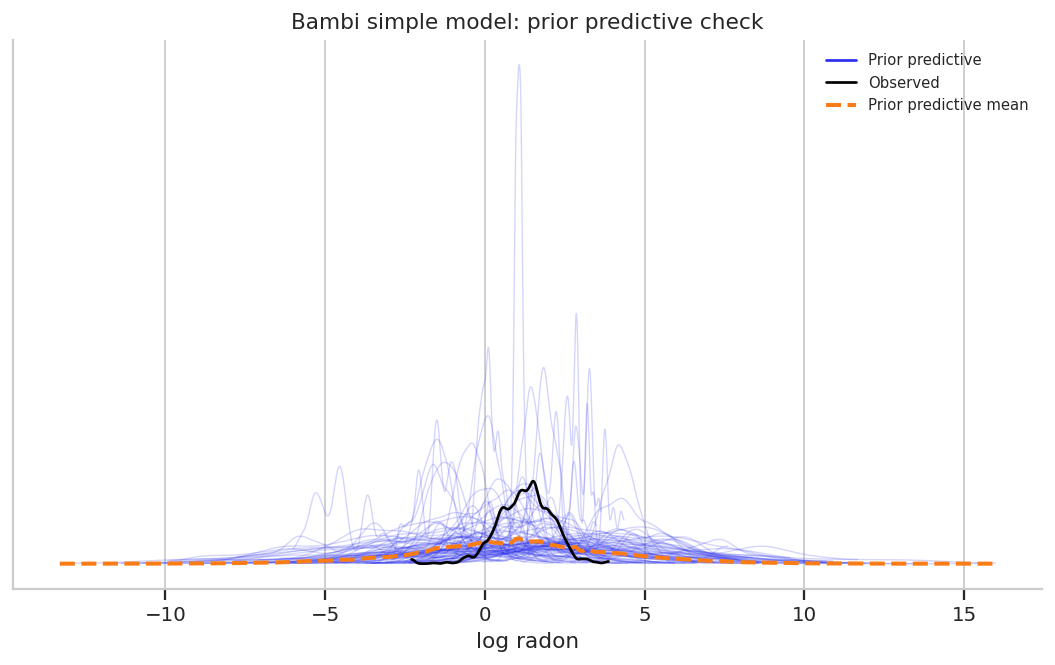

In [ ]:
# Prior predictive check
# This creates a Bambi prior predictive InferenceData object.

idata_bambi_simple_prior = bambi_simple_model.prior_predictive(draws=1000, random_seed=RANDOM_SEED)

az.plot_ppc( idata_bambi_simple_prior,group="prior", observed=True, num_pp_samples=100,)
plt.title("Bambi simple model: prior predictive check")
plt.xlabel("log radon")
plt.show()


In [ ]:
# Diagnostics and plotting as usual
az.summary(idata_bambi_simple, hdi_prob=HDI_MASS).round(3)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.264,0.026,1.214,1.313,0.0,0.0,4314.0,2877.0,1.0
sigma,0.777,0.019,0.741,0.810,0.0,0.0,4394.0,3311.0,1.0
uranium_z,0.267,0.026,0.219,0.318,0.0,0.0,4072.0,3014.0,1.0


/tmp/ipykernel_2275/3560499502.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


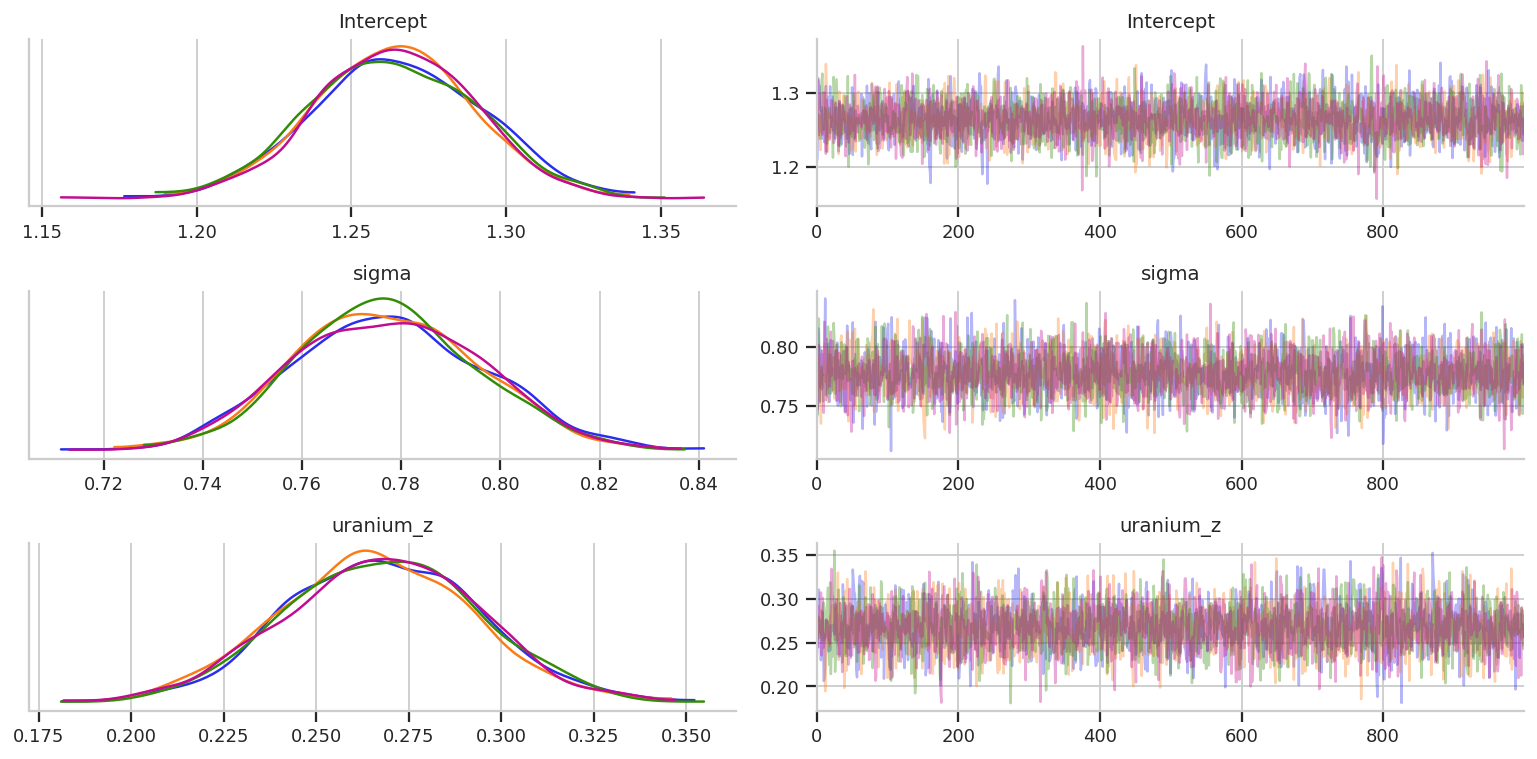

In [ ]:
az.plot_trace(idata_bambi_simple, var_names=['Intercept', 'sigma', 'uranium_z'], compact=False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2275/2340746462.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


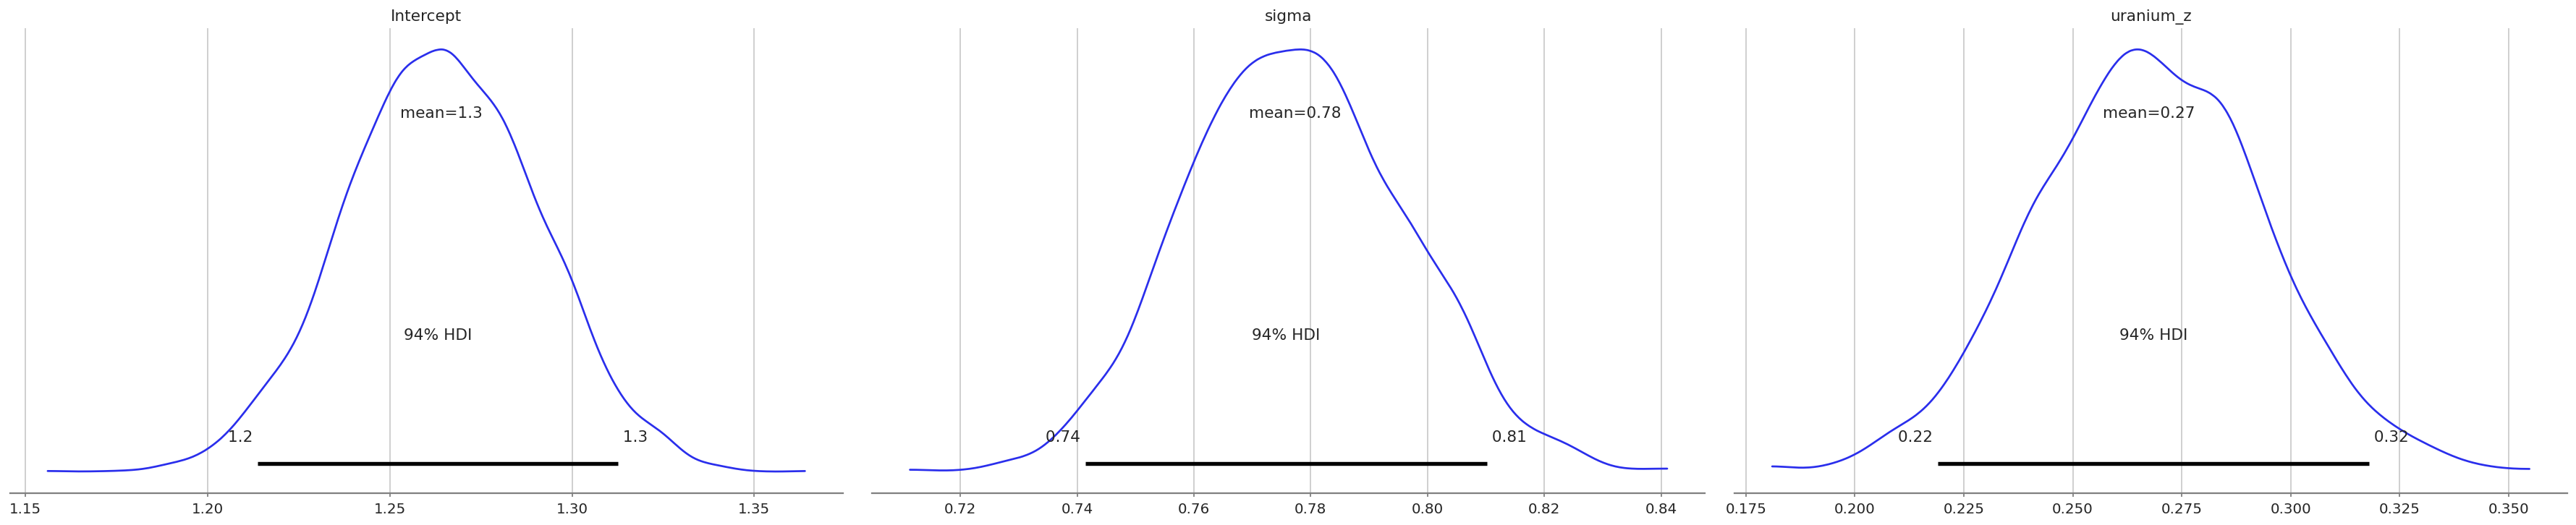

In [ ]:
az.plot_posterior(idata_bambi_simple, var_names=['Intercept', 'sigma', 'uranium_z'], hdi_prob=HDI_MASS)
plt.tight_layout()
plt.show()

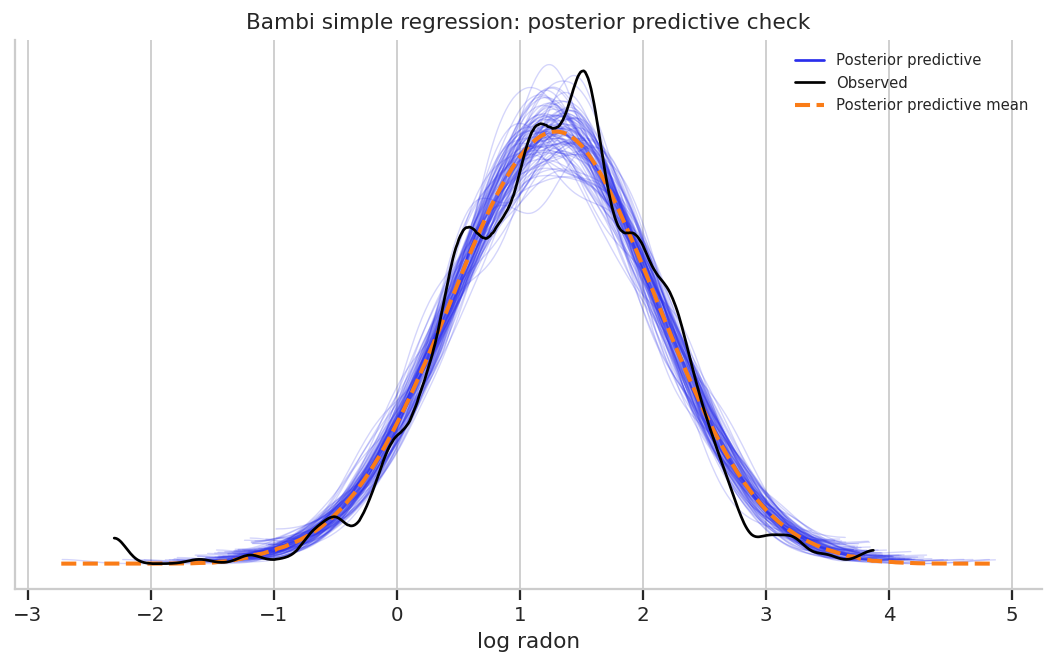

In [ ]:
# Posterior predictive check
bambi_simple_model.predict(
        idata_bambi_simple,
        kind="pps",
        inplace=True,
        random_seed=RANDOM_SEED)

az.plot_ppc(
        idata_bambi_simple,
        group="posterior",
        observed=True,
        num_pp_samples=100)

plt.title("Bambi simple regression: posterior predictive check")
plt.xlabel("log radon")
plt.show()


### Things we can do in Bambi:

1.   Choose our own priors
2.   omit the intercept




In [ ]:
# Defining our oun priors
my_priors = {
    "beta0": bmb.Prior("Normal", mu=y_mean, sigma=2 * y_sd),
    "beta_uranium": bmb.Prior("Normal", mu=0, sigma=1),
    "sigma": bmb.Prior("HalfNormal", sigma=y_sd),
}

# Create the model using Bambi
bambi_simple_model_our_priors = bmb.Model("log_radon ~ uranium_z", data=radon, priors=my_priors)
print(bambi_simple_model_our_priors)

       Formula: log_radon ~ uranium_z
        Family: gaussian
          Link: mu = identity
  Observations: 878
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.2641, sigma: 2.0511)
            uranium_z ~ Normal(mu: 0.0, sigma: 2.0523)
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 0.8209)


In [ ]:
# Option 1
no_intercept_model1 = bmb.Model("log_radon ~ 0 + uranium_z ", data=radon)
print(no_intercept_model1)

       Formula: log_radon ~ 0 + uranium_z 
        Family: gaussian
          Link: mu = identity
  Observations: 878
        Priors: 
    target = mu
        Common-level effects
            uranium_z ~ Normal(mu: 0.0, sigma: 2.0523)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.8204)


In [ ]:
# Option 2
no_intercept_model2 = bmb.Model("log_radon ~ -1 + uranium_z", data=radon)
print(no_intercept_model2)

       Formula: log_radon ~ -1 + uranium_z
        Family: gaussian
          Link: mu = identity
  Observations: 878
        Priors: 
    target = mu
        Common-level effects
            uranium_z ~ Normal(mu: 0.0, sigma: 2.0523)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.8204)


## 21. Multiple regression with Bambi

In [ ]:
bambi_multiple_model = bmb.Model("log_radon ~ uranium_z + basement_num", data=radon)
bambi_multiple_model

       Formula: log_radon ~ uranium_z + basement_num
        Family: gaussian
          Link: mu = identity
  Observations: 878
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.2641, sigma: 7.9123)
            uranium_z ~ Normal(mu: 0.0, sigma: 2.0523)
            basement_num ~ Normal(mu: 0.0, sigma: 8.1924)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.8204)

In [ ]:
idata_bambi_multiple = bambi_multiple_model.fit(
    draws=1000,
    chains=4,
    random_seed=RANDOM_SEED,
    target_accept=0.9,
)

print_divergences(idata_bambi_multiple, "Bambi multiple model")

Output()

Number of divergences in Bambi multiple model: 0


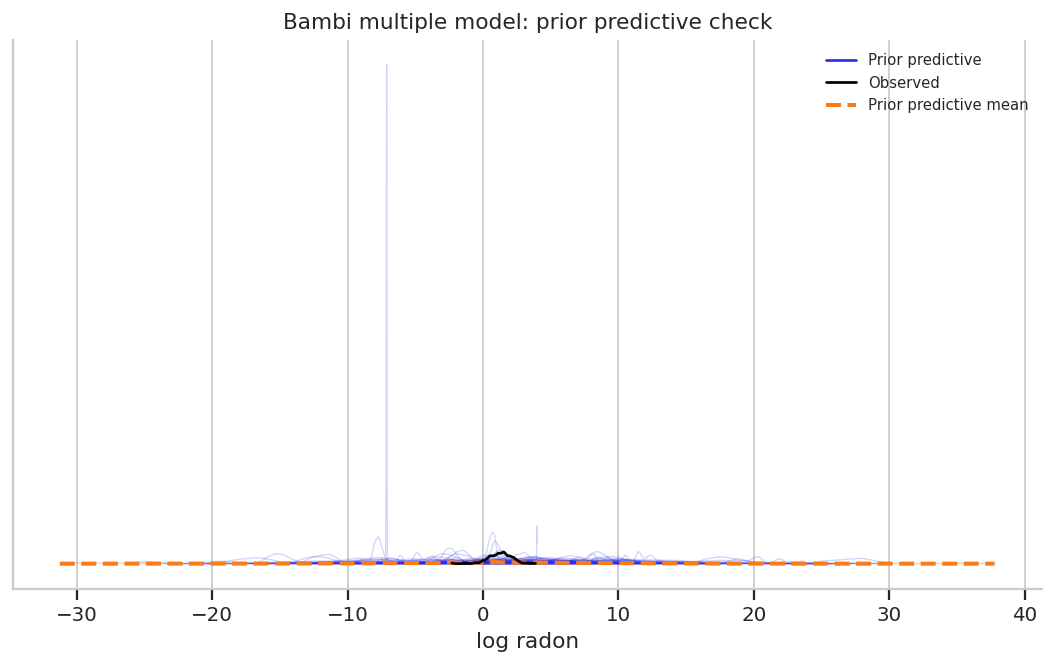

In [ ]:
# Prior predictive check
idata_bambi_multiple_prior = bambi_multiple_model.prior_predictive(draws=1000, random_seed=RANDOM_SEED)

az.plot_ppc(idata_bambi_multiple_prior, group="prior", observed=True, num_pp_samples=100,)
plt.title("Bambi multiple model: prior predictive check")
plt.xlabel("log radon")
plt.show()


In [ ]:
az.summary(idata_bambi_multiple, var_names=['Intercept', 'sigma', 'uranium_z', 'basement_num'],
           kind='diagnostics',
           hdi_prob=HDI_MASS).round(3)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.001,0.002,5024.0,3029.0,1.0
sigma,0.000,0.000,4419.0,3006.0,1.0
uranium_z,0.000,0.000,3964.0,3143.0,1.0
basement_num,0.001,0.002,4903.0,3034.0,1.0


/tmp/ipykernel_2275/3396201809.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


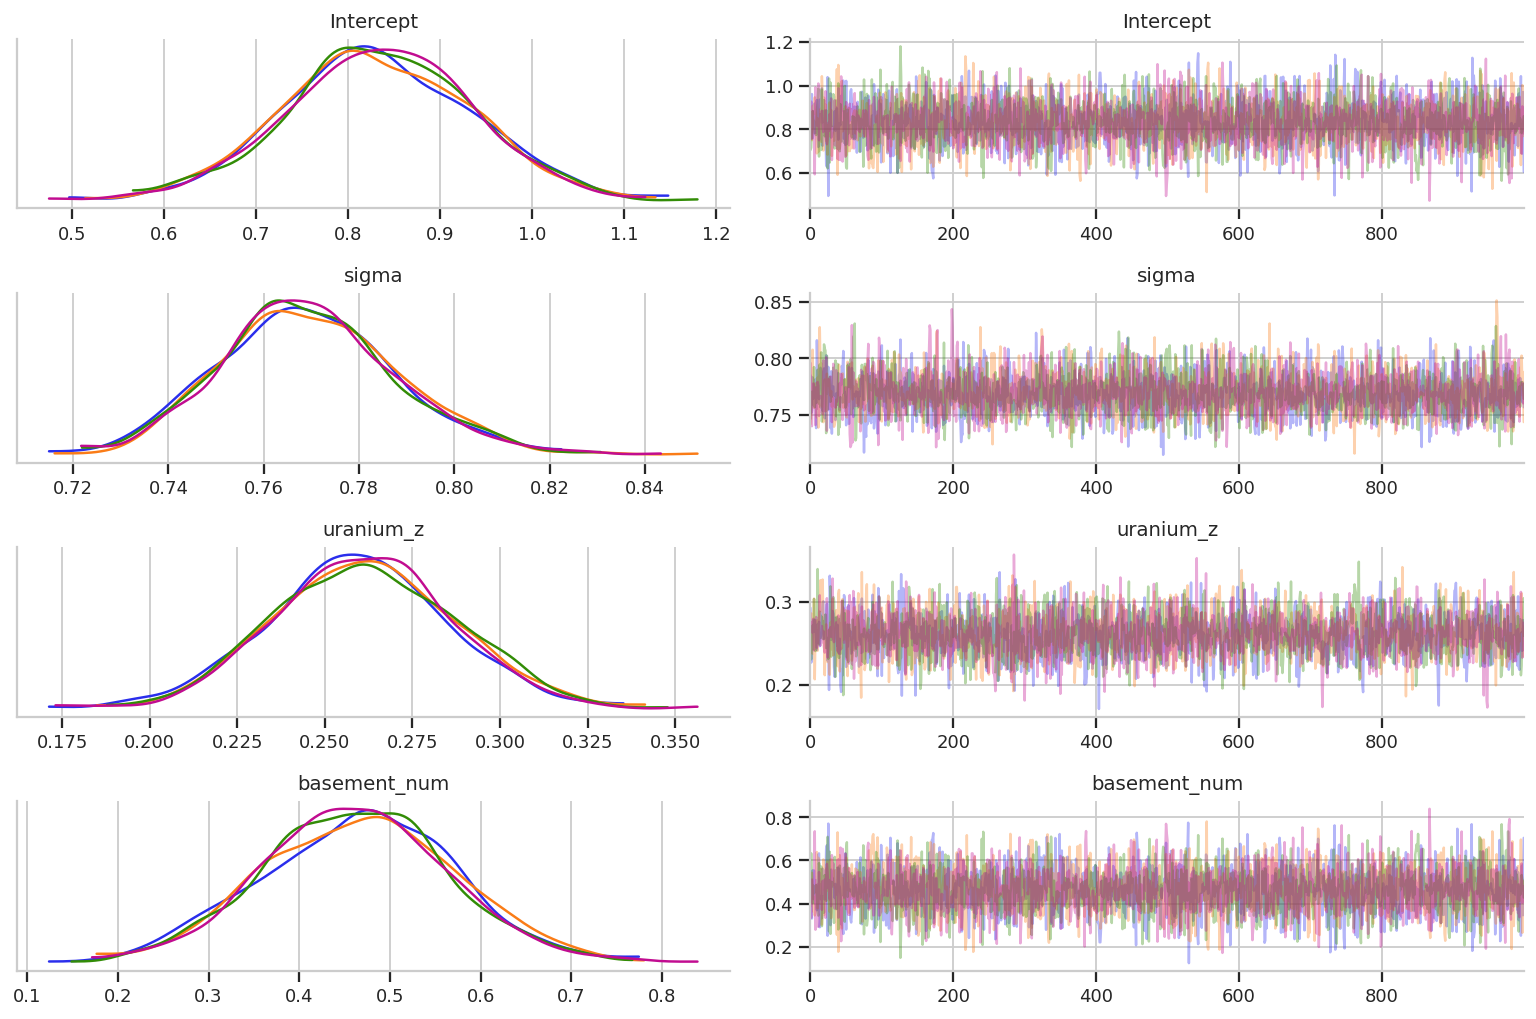

In [ ]:
az.plot_trace(idata_bambi_multiple, var_names=['Intercept', 'sigma', 'uranium_z', 'basement_num'], compact=False)
plt.tight_layout()
plt.show()

In [ ]:
az.summary(idata_bambi_multiple, var_names=['Intercept', 'sigma', 'uranium_z', 'basement_num'],
           kind='stats',
           hdi_prob=HDI_MASS).round(3)

,mean,sd,hdi_3%,hdi_97%
Intercept,0.832,0.101,0.642,1.024
sigma,0.769,0.018,0.735,0.803
uranium_z,0.261,0.026,0.211,0.306
basement_num,0.463,0.104,0.266,0.656


/tmp/ipykernel_2275/3359333713.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


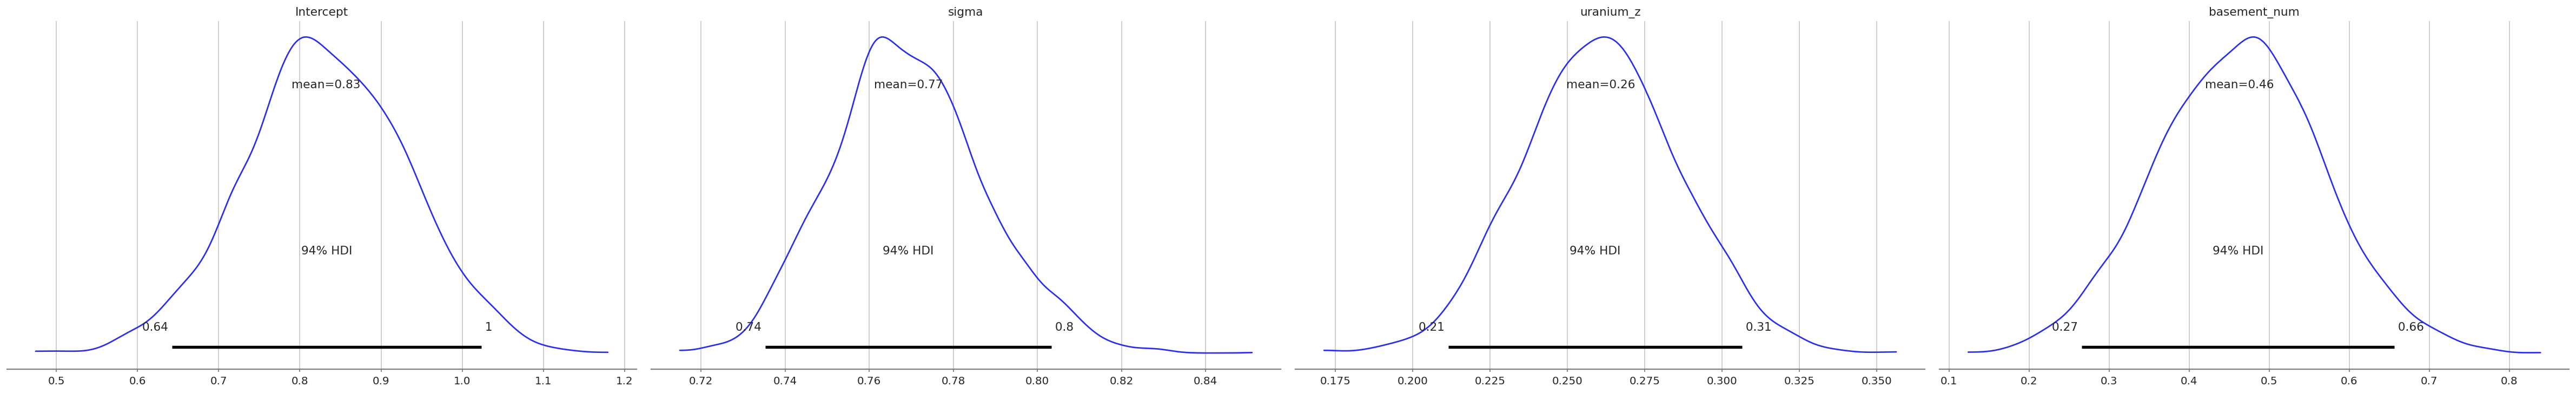

In [ ]:
az.plot_posterior(idata_bambi_multiple, var_names=['Intercept', 'sigma', 'uranium_z', 'basement_num'], hdi_prob=HDI_MASS)
plt.tight_layout()
plt.show()

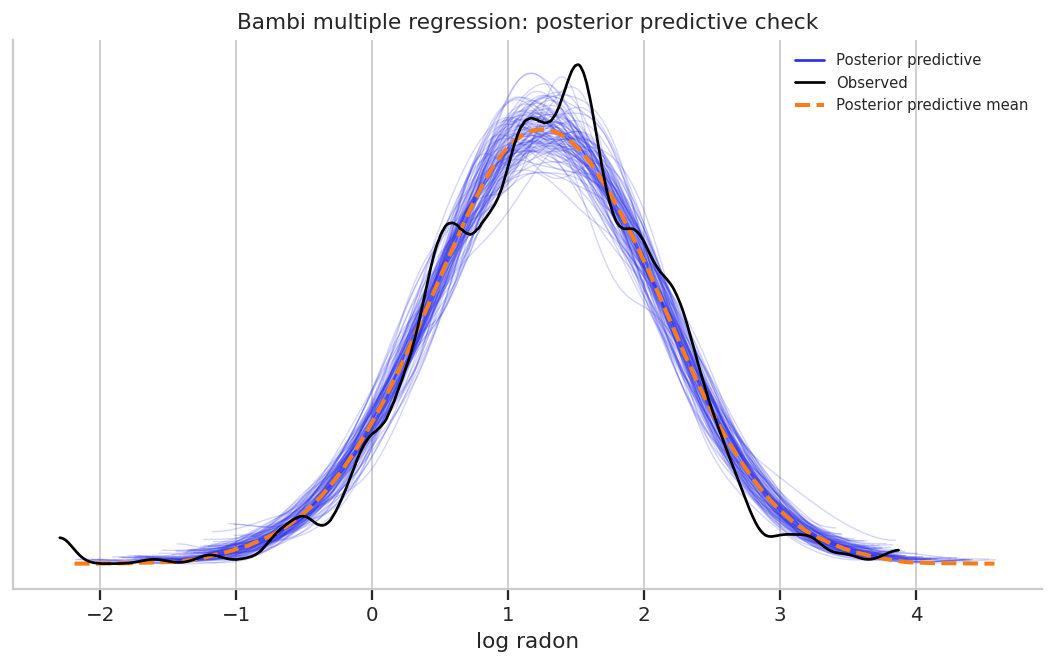

In [ ]:
try:
    bambi_multiple_model.predict(
        idata_bambi_multiple,
        kind="pps",
        inplace=True,
        random_seed=RANDOM_SEED + 10,
    )

    az.plot_ppc(idata_bambi_multiple, group="posterior", observed=True, num_pp_samples=100)
    plt.title("Bambi multiple regression: posterior predictive check")
    plt.xlabel("log radon")
    plt.show()
except Exception as error:
    print("Bambi posterior predictive plotting was skipped because of a version/API issue:")
    print(error)

# Part D — Frequentist linear regression

We now fit the same models using ordinary least squares (OLS) with `statsmodels`.

The frequentist model uses the same linear equation, but the interpretation changes:

- Bayesian model: posterior distributions over parameters.
- Frequentist OLS: point estimates, standard errors, confidence intervals, t-tests, and p-values.

## 23. Simple and multiple OLS models

In [ ]:
# Simple linear regression model
ols_simple = smf.ols("log_radon ~ uranium_z", data=radon).fit()

print("Simple OLS model")
print(ols_simple.summary())

In [ ]:
# Multiple regression model
ols_multiple = smf.ols("log_radon ~ uranium_z + basement_num", data=radon).fit()

print("\n\nMultiple OLS model")
print(ols_multiple.summary())

## 24. Extract the frequentist regression summaries

In [ ]:
# Helper function
def tidy_ols_results(result, model_name):
    table = pd.DataFrame({
        "model": model_name,
        "term": result.params.index,
        "estimate": result.params.values,
        "std_error": result.bse.values,
        "t_value": result.tvalues.values,
        "p_value": result.pvalues.values,
        "ci_low": result.conf_int().iloc[:, 0].values,
        "ci_high": result.conf_int().iloc[:, 1].values,
    })
    return table

In [ ]:
ols_coefficients = pd.concat([
    tidy_ols_results(ols_simple, "simple"),
    tidy_ols_results(ols_multiple, "multiple"),
], ignore_index=True)

display(ols_coefficients.round(4))

In [ ]:
ols_fit_summary = pd.DataFrame({
    "model": ["simple", "multiple"],
    "R2": [ols_simple.rsquared, ols_multiple.rsquared],
    "adjusted_R2": [ols_simple.rsquared_adj, ols_multiple.rsquared_adj],
    "F_statistic": [ols_simple.fvalue, ols_multiple.fvalue],
    "F_p_value": [ols_simple.f_pvalue, ols_multiple.f_pvalue],
    "df_model": [ols_simple.df_model, ols_multiple.df_model],
    "df_resid": [ols_simple.df_resid, ols_multiple.df_resid],
})

display(ols_fit_summary.round(4))

## 25. What does the $F$-test ask?

Individual t-tests ask whether one coefficient differs from zero.

The $F$-test asks whether the model as a whole explains more variability than a null model with no predictors.

For the multiple regression model:

$$H_0: beta_{uranium} = beta_{basement} = 0$$

$$H_1: \text{at least one predictor has a non-zero effect}$$

The $F$-test does not tell us which predictor is important. It tests the full model against an intercept-only null model.

In [ ]:
print("Multiple OLS model F-test")
print(f"F statistic: {ols_multiple.fvalue:.3f}")
print(f"p-value: {ols_multiple.f_pvalue:.6f}")
print(f"df model: {ols_multiple.df_model:.0f}")
print(f"df residual: {ols_multiple.df_resid:.0f}")

## 26. Bayesian vs frequentist regression summary

| Question | Bayesian regression | Frequentist OLS |
|---|---|---|
| What is the slope? | Posterior distribution | Point estimate |
| How uncertain are we? | HDI | Confidence interval |
| Does the model generate realistic data? | Posterior predictive check | Residual diagnostics / model summaries |
| How much variability is explained? | Bayesian $R^2$ distribution | $R^2$, adjusted $R^2$ |
| Is the whole model useful? | Model comparison / posterior interpretation | $F$-test |

The Bayesian and frequentist models can use a similar linear equation, but they answer questions using different inferential logic.



## 27. Final interpretation prompts

1. What is the dependent variable?
2. What are the independent variables?
3. What does each slope mean in domain terms?
4. Did the prior predictive check look plausible?
5. Did the sampling diagnostics look acceptable?
6. Did the posterior predictive check look reasonable?
7. How did the multiple regression coefficients differ from the simple regression coefficient?
8. How do Bayesian $R^2$ and frequentist $R^2$ compare?
9. What does the frequentist $F$-test say about the model as a whole?